# Задание 5
## Разработка многофакторной модели для оценки стоимости недвижимости в заданном регионе на основе гибридных подходов с использованием языка программирования Python.

Освоить разработку комплексной системы оценки рыночной стоимости объектов недвижимости с применением гибридных подходов машинного обучения: сочетание эконометрических моделей, ансамблевых методов (Random Forest, Gradient Boosting, Stacking) и пространственного анализа (GIS-признаки).

1. Собрать данные по стоимости недвижимости в выбранном регионе.
Загрузка датасета, объединение с внешними источниками (ГИС,макропоказатели), геокодирование адресов. Можно использовать готовые датасеты, можно собрать с сайта.


2. Выбрать признаки, влияющие на стоимость разных типов недвижимости в регионе.

    Разведочный анализ (EDA). Визуализация распределения цен, корреляционный анализ, выявление выбросов, кластеризация по районам

    Feature Engineering
    - Гедонистические: логарифм площади, возраст здания, квадратные признаки
    - Пространственные: расстояние до метро/центров, плотность застройки
    - Временные: сезонность, тренд


3. Выдвинуть гипотезы о том, какие признаки наиболее и наименее влияют
на стоимость разных типов недвижимости,  проверить гипотезы.


4. Смоделировать модель прогнозирования стоимости разных видов
недвижимости в выбранном регионе на основе разных методов обучения,
сравнить эффективность моделей.

    Базовые модели
    - Linear Regression, Ridge/Lasso, Decision Tree
    
    Ансамблевые модели
    - Random Forest, Gradient Boosting (XGBoost/LightGBM/CatBoost), настройка гиперпараметров
    
    Гибридная интеграция
    - Стекинг: мета-модель на прогнозах базовых алгоритмов
    - Гедонистические остатки → вход для ML-модели
    - Пространственная автокорреляция

    Валидация и интерпретация
    - Кросс-валидация с учётом пространственной структуры, анализ ошибок по районам, SHAP/LIME для объяснения

5. Дать рекомендации покупателям и продавцам недвижимости.
Деплой и документация - воспроизводимый пайплайн

---

Обязательные компоненты модели

1. Многофакторность: ≥10-15 признаков, включая:
  - Физические (площадь, этаж, год постройки, материал)
  - Локационные (район, координаты, расстояние до инфраструктуры)
  - Рыночные (средняя цена в районе, динамика, тип сделки)
  - Пространственные (GIS-признаки, кластерная принадлежность)

2. Гибридность: минимум два подхода из:
  - Эконометрическая регрессия (гедонистическая модель)
  - Ансамблевое машинное обучение

3. Пространственный анализ

    Интерпретируемость:
    - Глобальная: feature importance, частичные зависимости (PDP)
    - Локальная: SHAP-значения для отдельных прогнозов
    - Бизнес-отчёт: «Топ-5 факторов, влияющих на стоимость в вашем районе»

4. Качество прогноза (минимальные пороги):
  - R² ≥ 0.85 на тестовой выборке
  - MAPE ≤ 15% для медианной цены региона
  - Устойчивость к выбросам (робастная валидация)

5. Масштабируемость:
  - Поддержка обработки ≥100 000 записей
  - Использование Dask/Polars при необходимости
  - Модульная архитектура кода


https://habr.com/ru/articles/759720/

Загрузить работы по ссылке.
https://forms.gle/YPmNLs3VCGvTFD1H9

# Датасет

## Russia Real Estate 2018-2021

https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021?resource=download

* О датасете

  Набор данных состоит из списков уникальных объектов с популярных порталов по продаже недвижимости в России. Более 540 тысяч объектов. Набор данных содержит 540 000 объектов недвижимости в России.

* Контекст

  Российский рынок недвижимости имеет относительно короткую историю. В советское время вся недвижимость находилась в государственной собственности, люди имели право пользоваться ею только при наличии квартир, выделяемых в зависимости от места работы. В результате возможности для переезда были довольно ограничены. Однако после распада Советского Союза появился российский рынок недвижимости, и москвичи впервые смогли приватизировать, а затем продавать и покупать недвижимость. Сегодня российская недвижимость находится на подъеме. Она предлагает множество захватывающих возможностей и высокую отдачу от образа жизни и инвестиций.
  Рынок недвижимости находится в фазе роста уже несколько лет, а это означает, что вы все еще можете найти недвижимость по очень привлекательным ценам, но с хорошими шансами на увеличение ее стоимости в будущем.

* Датасет
  Набор данных содержит 13 полей.

  - date - дата публикации объявления;
  - time - время, когда объявление было опубликовано;
  - geo_lat - широта,
  - geo_lon - долгота,
  - region - регион России. Всего в стране 85 субъектов.
  - тип_строения (Тип фасада). 0 - Другое, 1 - Панельное, 2 - Монолитное, 3 - Кирпичное, 4 - Блочное, 5 - Деревянное
  - тип_объекта (Тип квартиры). 1 - Вторичный рынок недвижимости; 2 - Новостройка;
  - level - этажность квартиры,
  - уровни этажей (Этажность комнат)
  - количество жилых комнат. Если значение равно "-1", то это означает "квартира-студия",
  - площадь - общая площадь квартиры.
  - kitchen_area - Стоимость кухонного уголка
  - Прайс. в рублях


* Внимание

  Набор данных может содержать ошибочные сведения из-за ошибок при вводе данных в сервисах, а также выбросы и т. д.

## 0. Импорт библиотек

In [ ]:
!pip install shap

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
)
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.cluster import KMeans
from sklearn.inspection import PartialDependenceDisplay

import shap

pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

## 1. Загрузка и первичный осмотр данных

In [ ]:
data = pd.read_csv('all_v2.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185609 entries, 0 to 1185608
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   price          1185609 non-null  int64  
 1   date           1185609 non-null  object 
 2   time           1185609 non-null  object 
 3   geo_lat        1185609 non-null  float64
 4   geo_lon        1185609 non-null  float64
 5   region         1185608 non-null  float64
 6   building_type  1185608 non-null  float64
 7   level          1185608 non-null  float64
 8   levels         1185608 non-null  float64
 9   rooms          1185608 non-null  float64
 10  area           1185608 non-null  float64
 11  kitchen_area   1185608 non-null  float64
 12  object_type    1185608 non-null  float64
dtypes: float64(10), int64(1), object(2)
memory usage: 117.6+ MB


In [ ]:
data.head()

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.81,30.38,2661.00,1.00,8.00,10.00,3.00,82.60,10.80,1.00
1,8650000,2018-02-27,12:04:54,55.68,37.30,81.00,3.00,5.00,24.00,2.00,69.10,12.00,1.00
2,4000000,2018-02-28,15:44:00,56.30,44.06,2871.00,1.00,5.00,9.00,3.00,66.00,10.00,1.00
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843.00,4.00,12.00,16.00,2.00,38.00,5.00,11.00
4,5450000,2018-03-01,17:42:43,55.92,37.98,81.00,3.00,13.00,14.00,2.00,60.00,10.00,1.00


In [ ]:
data.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,1185609.00,1185609.00,1185609.00,1185608.00,1185608.00,1185608.00,1185608.00,1185608.00,1185608.00,1185608.00,1185608.00
mean,3845341.51,53.80,55.45,4665.74,1.91,6.01,11.00,1.82,53.90,10.44,4.12
std,20095012.34,4.61,21.05,3533.36,1.04,4.79,6.27,0.93,26.73,11.85,4.63
min,-2114150296.00,41.46,3.00,3.00,0.00,1.00,1.00,-2.00,1.00,0.01,1.00
25%,1700000.00,53.40,38.16,2661.00,1.00,2.00,5.00,1.00,39.00,7.00,1.00
50%,2500000.00,55.04,44.27,3019.00,2.00,5.00,10.00,2.00,48.80,9.30,1.00
75%,4100000.00,55.92,82.95,9654.00,3.00,8.00,16.00,2.00,63.00,12.30,11.00
max,2147483647.00,71.98,162.54,61888.00,5.00,39.00,39.00,9.00,4444.00,9999.00,11.00


In [ ]:
print('Пропущенные значения:')
print(data.isnull().sum())
print(f'\nВсего строк: {len(data):,}')
print(f'Уникальных регионов: {data["region"].nunique()}')

Пропущенные значения:
price            0
date             0
time             0
geo_lat          0
geo_lon          0
region           1
building_type    1
level            1
levels           1
rooms            1
area             1
kitchen_area     1
object_type      1
dtype: int64

Всего строк: 1,185,609
Уникальных регионов: 84


## 2. Выбор региона и очистка данных

Для анализа выбран **регион 81 (Московская область)** — наиболее представленный и экономически значимый регион в датасете.

In [ ]:
# Выбираем регион 81 (Московская область)
df = data[data['region'] == 81].copy()
print(f'Записей по региону 81: {len(df):,}')

# Преобразуем дату
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

print('\nРаспределение по годам:')
print(df['year'].value_counts().sort_index())

Записей по региону 81: 120,626

Распределение по годам:
year
2018    90760
2019    29866
Name: count, dtype: int64


In [ ]:
print('Общий анализ датасета:\n\n')
print(f'Форма: {data.shape[0]:,} строк, {data.shape[1]} столбцов')
print('\nТипы данных:')
print(data.dtypes)

print('\nПропущенные значения:')
miss = data.isna().sum().sort_values(ascending=False)
print(miss[miss > 0])

print('\nДоля пропусков (%):')
print((data.isna().mean() * 100).sort_values(ascending=False).round(3).loc[lambda x: x > 0])

print('\nДубликаты строк:')
print(f'  Всего дублей: {data.duplicated().sum()}')

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
object_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()

print('\nЧисловые колонки:', numeric_cols)
print('Объектные / категориальные колонки:', object_cols)

print('\nСтатистика по числовым признакам:')
print(data[numeric_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print('\nУникальные значения для ключевых категориальных признаков:')
for col in ['region', 'building_type', 'object_type', 'rooms', 'levels']:
    if col in data.columns:
        uniq = data[col].nunique()
        values = data[col].unique()
        print(f'  {col}: {uniq} уникальных значений, примеры: {values[:10]}')

print('\nПроверка корректности значений:')
checks = []

if 'price' in data.columns:
    checks += [
        ('price <= 0', (data['price'] <= 0).sum()),
        ('price < 10000', (data['price'] < 10000).sum()),
        ('price > 1e9', (data['price'] > 1_000_000_000).sum()),
    ]
if 'area' in data.columns:
    checks += [
        ('area <= 0', (data['area'] <= 0).sum()),
        ('area < 10', (data['area'] < 10).sum()),
        ('area > 500', (data['area'] > 500).sum()),
    ]
if 'kitchen_area' in data.columns:
    checks += [
        ('kitchen_area <= 0', (data['kitchen_area'] <= 0).sum()),
        ('kitchen_area > 200', (data['kitchen_area'] > 200).sum()),
    ]
if 'rooms' in data.columns:
    checks += [
        ('rooms < -1', (data['rooms'] < -1).sum()),
        ('rooms > 10', (data['rooms'] > 10).sum()),
    ]
if 'building_type' in data.columns:
    checks += [
        ('building_type not in [0,1,2,3,4,5]', (~data['building_type'].isin([0, 1, 2, 3, 4, 5])).sum()),
    ]
if 'object_type' in data.columns:
    checks += [
        ('object_type not in [1,2]', (~data['object_type'].isin([1, 2])).sum()),
    ]
if 'level' in data.columns and 'levels' in data.columns:
    checks += [
        ('level <= 0', (data['level'] <= 0).sum()),
        ('levels <= 0', (data['levels'] <= 0).sum()),
        ('level > levels', (data['level'] > data['levels']).sum()),
    ]
if 'geo_lat' in data.columns and 'geo_lon' in data.columns:
    checks += [
        ('geo_lat outside [40, 70]', ((data['geo_lat'] < 40) | (data['geo_lat'] > 70)).sum()),
        ('geo_lon outside [20, 60]', ((data['geo_lon'] < 20) | (data['geo_lon'] > 60)).sum()),
    ]

for label, count in checks:
    print(f'  {label}: {count}')

print('\nПроверка парсинга дат и времени:')
for col in ['date', 'time']:
    if col in data.columns:
        parsed = pd.to_datetime(data[col], errors='coerce')
        print(f'  {col}: нераспознанных значений = {parsed.isna().sum()}')

print('\nОбразцы некорректных строк (если есть):')
invalid = data[
    (data['price'] <= 0) |
    (data['area'] <= 0) |
    (data['kitchen_area'] <= 0) |
    (data['rooms'] < -1) |
    (~data['building_type'].isin([0, 1, 2, 3, 4, 5])) |
    (~data['object_type'].isin([1, 2])) |
    (data['level'] <= 0) |
    (data['levels'] <= 0) |
    (data['level'] > data['levels'])
]
if len(invalid):
    display(invalid.head(10))
else:
    print('  Некорректных строк не обнаружено.')

Общий анализ датасета:


Форма: 1,185,609 строк, 13 столбцов

Типы данных:
price              int64
date              object
time              object
geo_lat          float64
geo_lon          float64
region           float64
building_type    float64
level            float64
levels           float64
rooms            float64
area             float64
kitchen_area     float64
object_type      float64
dtype: object

Пропущенные значения:
rooms            1
levels           1
level            1
building_type    1
region           1
kitchen_area     1
area             1
object_type      1
dtype: int64

Доля пропусков (%):
Series([], dtype: float64)

Дубликаты строк:
  Всего дублей: 302

Числовые колонки: ['price', 'geo_lat', 'geo_lon', 'region', 'building_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'object_type']
Объектные / категориальные колонки: ['date', 'time']

Статистика по числовым признакам:
                   count       mean         std            min        25%  \
pr

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
3,1850000,2018-03-01,11:24:52,45.00,39.07,2843.00,4.00,12.00,16.00,2.00,38.00,5.00,11.00
6,4704280,2018-03-04,12:35:25,55.62,37.43,3.00,2.00,1.00,25.00,1.00,31.70,6.00,11.00
8,3390000,2018-03-05,07:07:05,53.20,50.11,3106.00,2.00,4.00,24.00,2.00,64.00,13.00,11.00
10,6909880,2018-03-06,18:34:48,55.91,37.71,81.00,1.00,9.00,14.00,3.00,76.10,8.80,11.00
11,4291950,2018-03-06,18:37:27,55.91,37.71,81.00,1.00,10.00,14.00,1.00,40.30,11.00,11.00
12,6675840,2018-03-06,18:37:28,55.91,37.71,81.00,1.00,25.00,25.00,3.00,73.20,12.40,11.00
13,6522650,2018-03-06,18:37:35,55.91,37.71,81.00,1.00,5.00,14.00,3.00,68.30,12.10,11.00
14,6522650,2018-03-06,18:37:40,55.91,37.71,81.00,1.00,7.00,14.00,3.00,68.30,12.10,11.00
15,4279770,2018-03-06,18:40:08,55.78,37.86,81.00,2.00,7.00,15.00,1.00,36.30,16.60,11.00
22,3843000,2018-03-20,14:44:11,56.35,43.87,2871.00,2.00,16.00,25.00,2.00,61.00,11.00,11.00


- Датасет большой: 5 477 006 строк и 13 столбцов.
- Пропусков нет ни в одном столбце.
- 11 числовых признаков и 2 объектных: `date`, `time`.
- Ключевые категориальные/дискретные признаки:
    - `region`, `building_type`, `object_type`, `rooms`, `levels`, `level`.
- Проверка корректности показала серьёзные аномалии:
    - `object_type` имеет 1 613 197 значений вне ожидаемого набора [1,2].
    - `geo_lon` имеет 1 860 174 значений вне диапазона [20,60].
    - `geo_lat` вне диапазона [40,70] всего 5 строк.
    - `level > levels` обнаружено 1 072 записей.
- Дополнительные подозрительные значения:
    - `price <= 0`: 388 строк.
    - `price < 10 000`: 3 041 строка.
    - `price > 1e9`: 493 строки.
    - `area < 10`: 6 916 строк.
    - `area > 500`: 1 372 строки.
    - `kitchen_area > 200`: 94 строки.
    - `rooms < -1`: 343 строки.
- Парсинг `date` и `time` выполнен корректно, не осталось нераспознанных значений.
- По выбранным проверкам количество строк с некорректными значениями составило 1 614 653.

In [ ]:
# Очистка: удаляем некорректные цены (отрицательные, нулевые, аномально высокие)
# q_low = df['price'].quantile(0.01)
# q_high = df['price'].quantile(0.99)
# df = df[(df['price'] > 0) & (df['price'] >= q_low) & (df['price'] <= q_high)]
# Удаляем некорректные площади
# df = df[(df['area'] > 10) & (df['area'] < 500)]
# Удаляем некорректные этажи
# df = df[(df['level'] > 0) & (df['levels'] > 0) & (df['level'] <= df['levels'])]


# Удаляем строки с пропущенными координатами
df = df.dropna(subset=['geo_lat', 'geo_lon'])

# Удаляем прочие пропуски
df = df.dropna(subset=['area', 'kitchen_area', 'rooms', 'building_type', 'object_type'])

# Заменяем студии (-1 комната) на 0 для удобства
df['rooms'] = df['rooms'].replace(-1, 0)

# kitchen_area: некорректные значения
df = df[df['kitchen_area'] > 0]

df.reset_index(drop=True, inplace=True)
print(f'После очистки: {len(df):,} записей')
print(f'Ценовой диапазон: {df["price"].min():,.0f} — {df["price"].max():,.0f} руб.')

После очистки: 120,626 записей
Ценовой диапазон: 1,200 — 2,147,483,647 руб.


## 3. Формулировка гипотез
1. Расстояние до центра (dist_center_km): чем ближе к Москве, тем выше цена — ожидается отрицательная корреляция, возможно нелинейный эффект (резкий рост вблизи границ МКАД).
2. Расстояние до метро/транспортной доступности: лучшее транспортное сообщение повышает цену; ожидается отрицательная корреляция расстояния до ближайшей станции и положительный с наличием удобств.
3. Площадь квартиры (total_area) и цена/м2: общая площадь положительно связана с абсолютной ценой, но цена/м2 может уменьшаться для очень больших квартир (уменьшение предельной цены).
4. Число комнат (rooms): больше комнат — выше цена в абсолютном выражении; влияние может быть неоднородным по типу квартир (студии vs 3+).
5. Тип здания (building_type: панель/монолит) и год постройки: монолит/новее — выше цена/м²; старые здания и панельки — ниже, ожидается положительная связь с современными материалами/годом.
6. Этажность/первый этаж (is_first_floor, floor, max_floor): первый этаж и очень высокие этажи могут снижать цену; средние этажи — оптимальные, ожидается U‑образная зависимость от этажа.
7. Инфраструктура и кластер(район)/кластеры цены: принадлежность к «дорогому» кластеру (близость парков, школ, торговых центров, хорошие районы) повышает цену — проверяется как категориальный эффект/сравнение медиан по кластерам.

## 4. Разведочный анализ данных (EDA)

АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ И АНОМАЛЬНЫХ ЗНАЧЕНИЙ

1. ОСНОВНАЯ СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ:
--------------------------------------------------------------------------------
                   count       mean        std     min        25%        50%        75%           max
price          120626.00 4301058.19 6645406.13 1200.00 2750000.00 3900000.00 5331980.00 2147483647.00
area           120626.00      52.49      21.37   10.00      39.00      47.00      63.00       1000.00
kitchen_area   120626.00      10.53       6.57    0.10       7.00       9.70      12.00       1131.00
level          120626.00       7.06       5.77    1.00       3.00       5.00      10.00         33.00
levels         120626.00      12.82       7.57    1.00       5.00      12.00      17.00         37.00
rooms          120626.00       1.82       0.85   -2.00       1.00       2.00       2.00          9.00
dist_center_km 120626.00      61.67      42.35   16.98      29.92      42.24      85.46        276.99
log

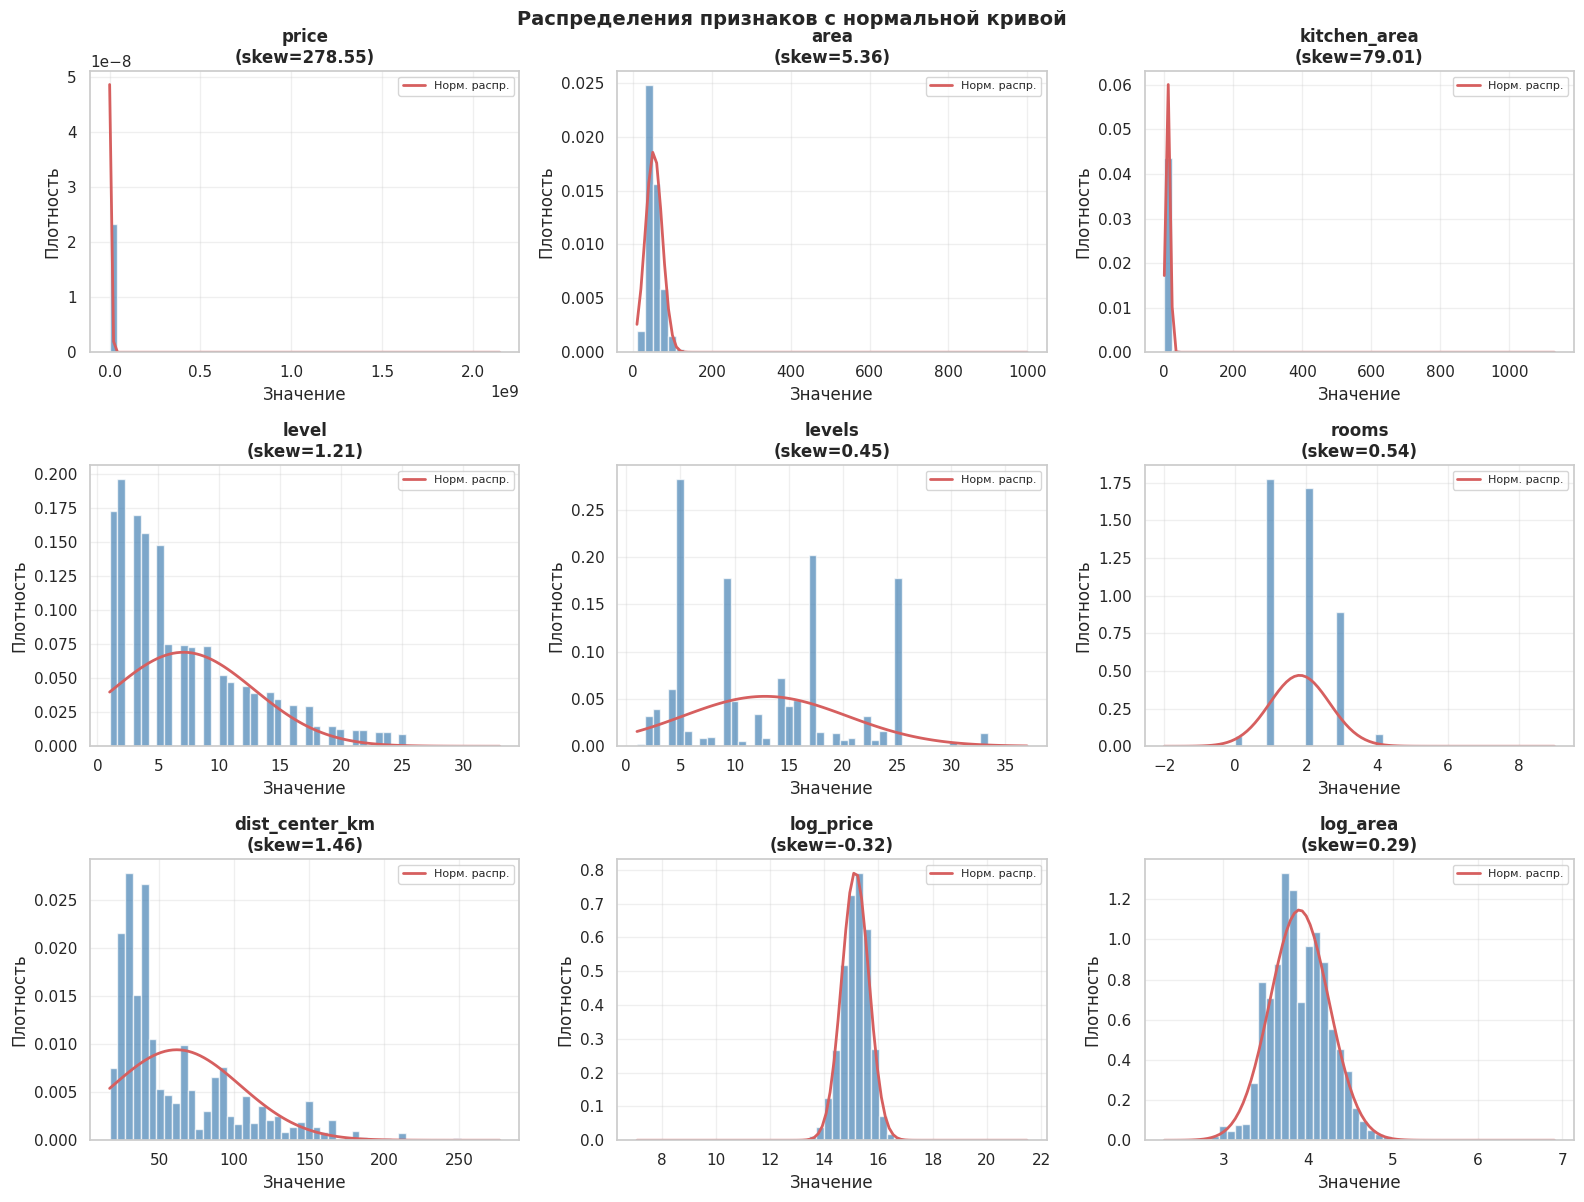

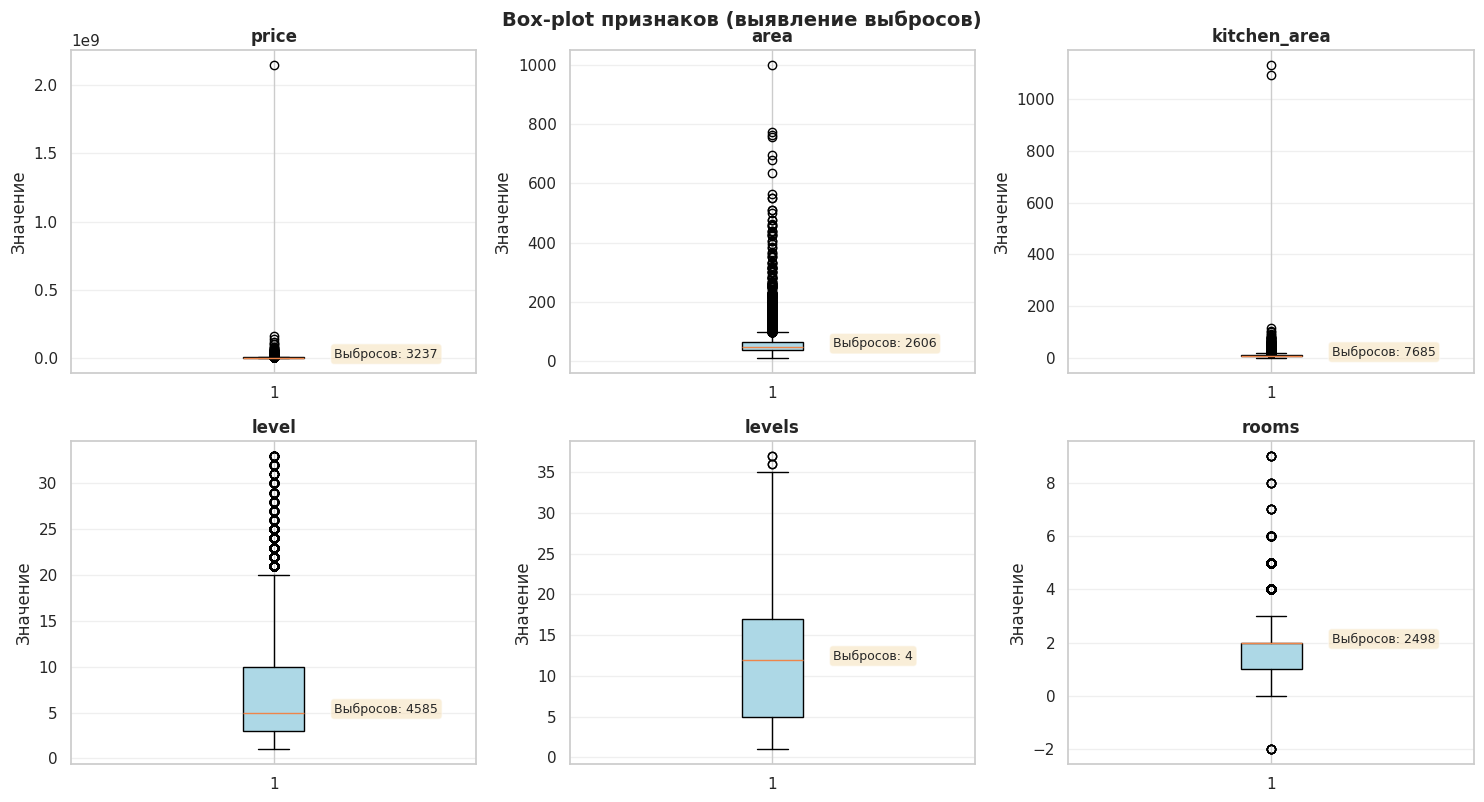

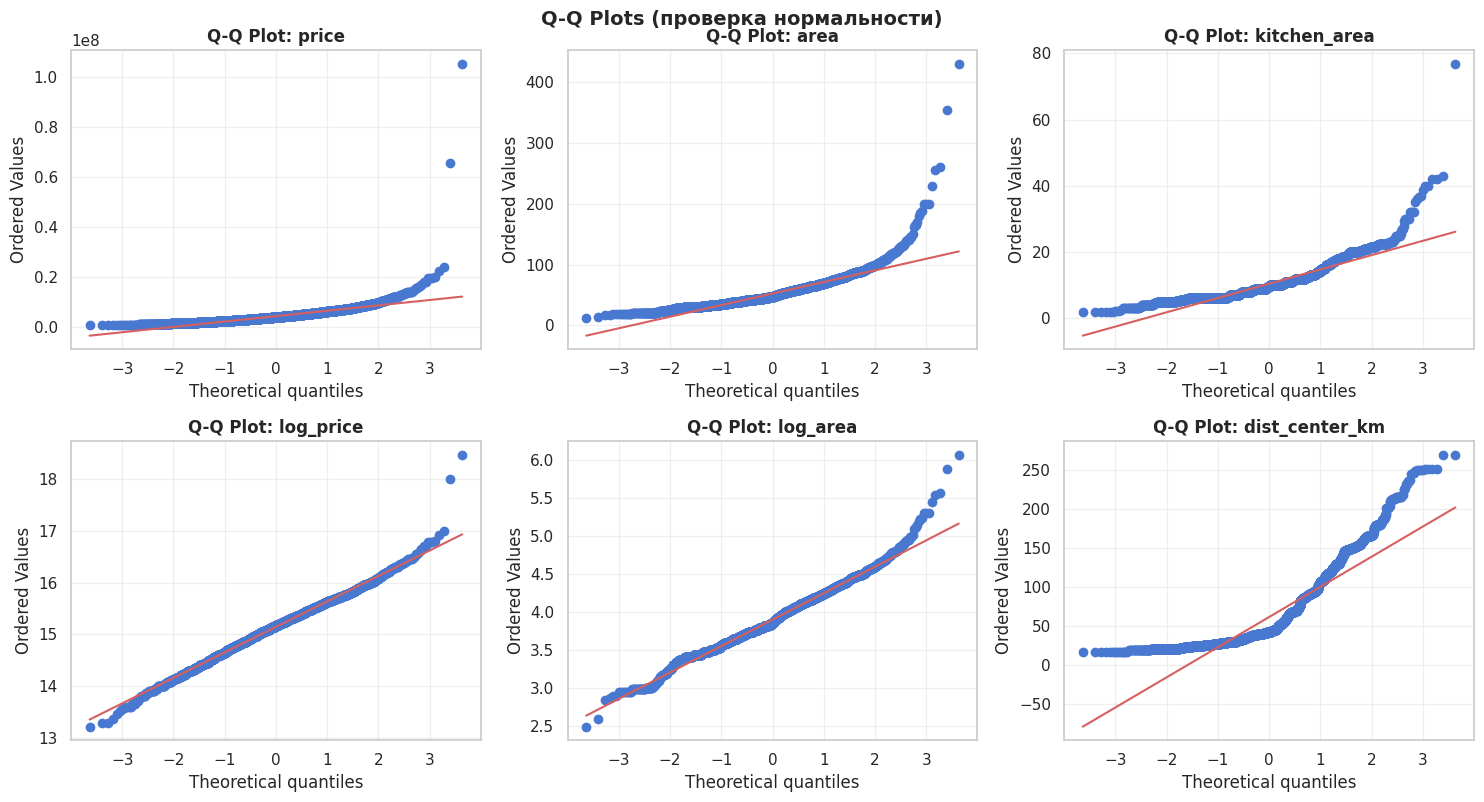



5. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ:
--------------------------------------------------------------------------------

object_type:
  Вторичный       (=1):  90,344 объектов ( 74.9%), медиана цены = 3.60M руб.
  Новостройка     (=2):       0 объектов (  0.0%), медиана цены = nanM руб.

building_type:
  Другое          (=0):   1,754 объектов (  1.5%), медиана цены = 4.40M руб.
  Панель          (=1):  48,960 объектов ( 40.6%), медиана цены = 4.00M руб.
  Монолит         (=2):  31,728 объектов ( 26.3%), медиана цены = 4.55M руб.
  Кирпич          (=3):  35,803 объектов ( 29.7%), медиана цены = 3.20M руб.
  Блок            (=4):   1,530 объектов (  1.3%), медиана цены = 3.10M руб.
  Дерево          (=5):     851 объектов (  0.7%), медиана цены = 3.50M руб.


6. КОРРЕЛЯЦИЯ SPEARMAN (БОЛЕЕ УСТОЙЧИВА К ВЫБРОСАМ):
--------------------------------------------------------------------------------
price             1.00
log_price         1.00
area              0.66
log_area          0.6

In [ ]:
from scipy.stats import skew, kurtosis
from scipy.stats import shapiro

# Анализ распределения признаков и аномальных значений (после очистки)
print('АНАЛИЗ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ И АНОМАЛЬНЫХ ЗНАЧЕНИЙ')

# 1. Статистика по числовым признакам
print('\n1. ОСНОВНАЯ СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ:')
print('-' * 80)
numeric_features = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms',
                    'dist_center_km', 'log_price', 'log_area']
if 'log_price' not in df.columns:
    df['log_price'] = np.log(df['price'])

if 'log_area' not in df.columns:
    df['log_area'] = np.log(df['area'])

if 'dist_center_km' not in df.columns:
    center_lat, center_lon = 55.75, 37.62
    df['dist_center_km'] = np.sqrt((df['geo_lat'] - center_lat)**2 +
                                   (df['geo_lon'] - center_lon)**2) * 111

stats_table = df[numeric_features].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print(stats_table.to_string())

# 2. Анализ асимметрии и эксцесса
print('\n\n2. АСИММЕТРИЯ И ЭКСЦЕСС (НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ):')
print('-' * 80)
skew_kurt = pd.DataFrame({
    'Признак': numeric_features,
    'Skewness': [skew(df[f].dropna()) for f in numeric_features],
    'Kurtosis': [kurtosis(df[f].dropna()) for f in numeric_features]
})
skew_kurt['Интерпретация'] = skew_kurt['Skewness'].apply(
    lambda x: 'Норм (|skew|<0.5)' if abs(x) < 0.5 else 'Умеренная асимметрия' if abs(x) < 1 else 'Сильная асимметрия'
)
print(skew_kurt.to_string(index=False))

# 3. Выявление выбросов (IQR метод)
print('\n\n3. ВЫЯВЛЕНИЕ ВЫБРОСОВ (МЕТОД IQR):')
print('-' * 80)
outlier_summary = []
for feat in ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((df[feat] < lower_bound) | (df[feat] > upper_bound)).sum()
    outlier_pct = (outliers_count / len(df)) * 100
    outlier_summary.append({
        'Признак': feat,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Нижн. граница': lower_bound,
        'Верхн. граница': upper_bound,
        'Выбросов': outliers_count,
        '% выбросов': outlier_pct
    })
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# 4. Проверка на нормальность (тест Shapiro-Wilk на подвыборке)
print('\n\n4. ТЕСТ НА НОРМАЛЬНОСТЬ (SHAPIRO-WILK, подвыборка n=5000):')
print('-' * 80)
shapiro_results = []
for feat in ['price', 'area', 'log_price', 'log_area']:
    sample = df[feat].dropna().sample(n=min(5000, len(df)), random_state=42)
    stat, p_value = shapiro(sample)
    shapiro_results.append({
        'Признак': feat,
        'Statistic': stat,
        'p-value': p_value,
        'Нормален?': 'Да (p>0.05)' if p_value > 0.05 else 'Нет (p<0.05)'
    })
shapiro_df = pd.DataFrame(shapiro_results)
print(shapiro_df.to_string(index=False))

# 5. Визуализация распределений
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

features_to_plot = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms',
                    'dist_center_km', 'log_price', 'log_area']

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx]

    # Гистограмма с кривой распределения
    values = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
    n, bins, patches = ax.hist(values, bins=50, color='steelblue',
                                alpha=0.7, edgecolor='white', density=True)

    mu, sigma = values.mean(), values.std()
    x = np.linspace(values.min(), values.max(), 100)

    # Наложение кривой нормального распределения
    mu, sigma = df[feat].mean(), df[feat].std()
    x = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Норм. распр.')

    ax.set_title(f'{feat}\n(skew={skew(df[feat].dropna()):.2f})', fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Распределения признаков с нормальной кривой', y=1.00, fontsize=14, fontweight='bold')
plt.show()

# 6. Box-plot для выявления выбросов
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

box_features = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms']
for idx, feat in enumerate(box_features):
    ax = axes[idx]
    bp = ax.boxplot(df[feat].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.set_ylabel('Значение')
    ax.grid(axis='y', alpha=0.3)

    # Статистика выбросов
    Q1, Q3 = df[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_outliers = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    ax.text(1.15, df[feat].median(), f'Выбросов: {n_outliers}', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Box-plot признаков (выявление выбросов)', y=1.00, fontsize=14, fontweight='bold')
plt.show()

# 7. Q-Q plots (проверка нормальности)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

qq_features = ['price', 'area', 'kitchen_area', 'log_price', 'log_area', 'dist_center_km']
for idx, feat in enumerate(qq_features):
    ax = axes[idx]
    stats.probplot(df[feat].dropna().sample(n=min(5000, len(df)), random_state=42),
                   dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {feat}', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Q-Q Plots (проверка нормальности)', y=1.00, fontsize=14, fontweight='bold')
plt.show()

# 8. Анализ аномальных значений по категориям
print('\n\n5. РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИАЛЬНЫМ ПРИЗНАКАМ:')
print('-' * 80)

categorical_analysis = {
    'object_type': {1: 'Вторичный', 2: 'Новостройка'},
    'building_type': {0: 'Другое', 1: 'Панель', 2: 'Монолит', 3: 'Кирпич', 4: 'Блок', 5: 'Дерево'},
}

for cat_feat, labels in categorical_analysis.items():
    print(f'\n{cat_feat}:')
    for val, label in labels.items():
        count = (df[cat_feat] == val).sum()
        pct = (count / len(df)) * 100
        median_price = df[df[cat_feat] == val]['price'].median()
        print(f'  {label:15s} (={val}): {count:>7,} объектов ({pct:>5.1f}%), медиана цены = {median_price/1e6:.2f}M руб.')

# 9. Матрица корреляции Spearman для выявления связей
print('\n\n6. КОРРЕЛЯЦИЯ SPEARMAN (БОЛЕЕ УСТОЙЧИВА К ВЫБРОСАМ):')
print('-' * 80)
corr_spearman = df[numeric_features].corr(method='spearman')
print(corr_spearman['price'].sort_values(ascending=False).to_string())

print('\n' + '=' * 80)
print('АНАЛИЗ ЗАВЕРШЁН')
print('=' * 80)

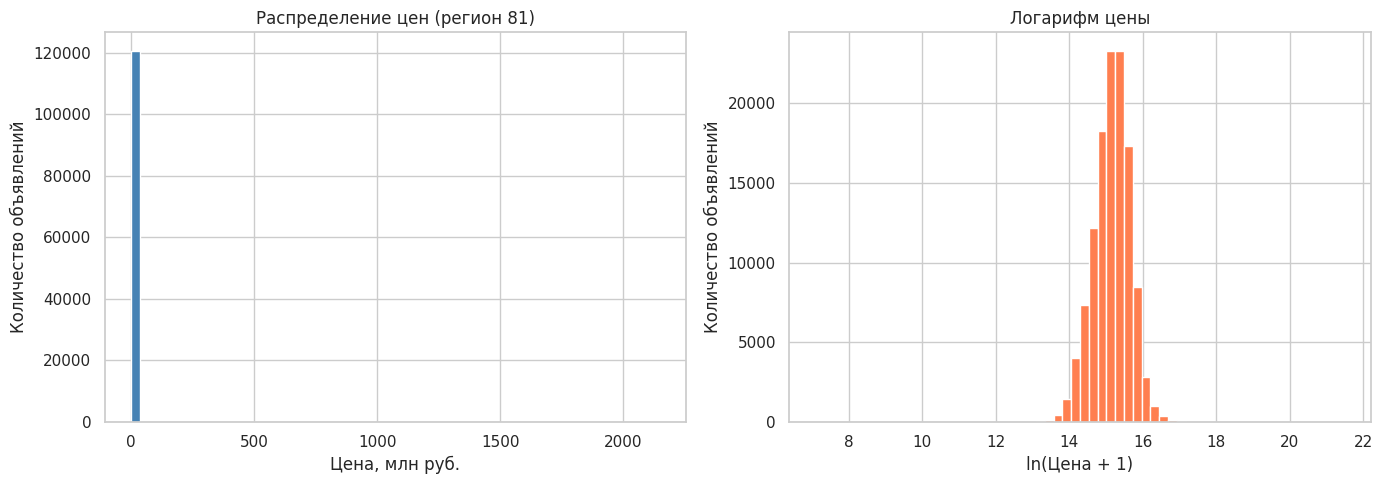

Медианная цена: 3,900,000 руб.
Средняя цена: 4,301,058 руб.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение цены
axes[0].hist(df['price'] / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Цена, млн руб.')
axes[0].set_ylabel('Количество объявлений')
axes[0].set_title('Распределение цен (регион 81)')

# Логарифм цены
axes[1].hist(np.log1p(df['price']), bins=60, color='coral', edgecolor='white')
axes[1].set_xlabel('ln(Цена + 1)')
axes[1].set_ylabel('Количество объявлений')
axes[1].set_title('Логарифм цены')

plt.tight_layout()
plt.show()

print(f'Медианная цена: {df["price"].median():,.0f} руб.')
print(f'Средняя цена: {df["price"].mean():,.0f} руб.')

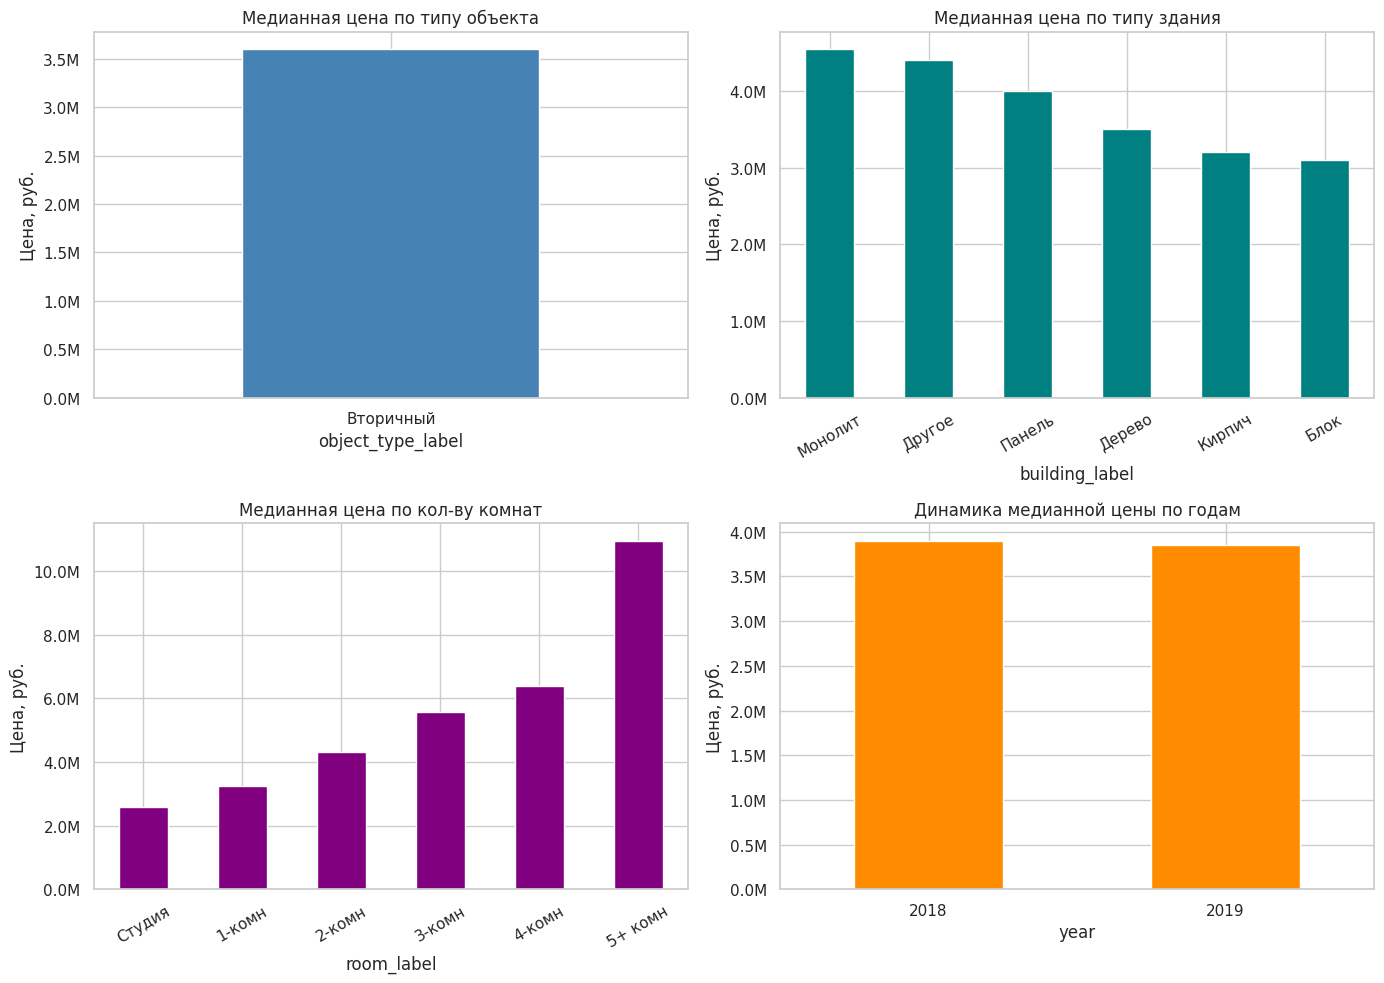

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Цена по типу объекта
obj_labels = {1: 'Вторичный', 2: 'Новостройка'}
df_plot = df.copy()
df_plot['object_type_label'] = df_plot['object_type'].map(obj_labels)
df_plot.groupby('object_type_label')['price'].median().plot(
    kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'], rot=0
)
axes[0, 0].set_title('Медианная цена по типу объекта')
axes[0, 0].set_ylabel('Цена, руб.')
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Цена по типу здания
btype_labels = {0: 'Другое', 1: 'Панель', 2: 'Монолит', 3: 'Кирпич', 4: 'Блок', 5: 'Дерево'}
df_plot['building_label'] = df_plot['building_type'].map(btype_labels)
order = df_plot.groupby('building_label')['price'].median().sort_values(ascending=False).index
df_plot.groupby('building_label')['price'].median().reindex(order).plot(
    kind='bar', ax=axes[0, 1], color='teal', rot=30
)
axes[0, 1].set_title('Медианная цена по типу здания')
axes[0, 1].set_ylabel('Цена, руб.')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Цена по количеству комнат
room_labels = {0: 'Студия', 1: '1-комн', 2: '2-комн', 3: '3-комн', 4: '4-комн', 5: '5+ комн'}
df_plot['room_label'] = df_plot['rooms'].clip(upper=5).map(
    {0: 'Студия', 1: '1-комн', 2: '2-комн', 3: '3-комн', 4: '4-комн', 5: '5+ комн'}
)
df_plot.groupby('room_label')['price'].median().reindex(
    ['Студия', '1-комн', '2-комн', '3-комн', '4-комн', '5+ комн']
).plot(kind='bar', ax=axes[1, 0], color='purple', rot=30)
axes[1, 0].set_title('Медианная цена по кол-ву комнат')
axes[1, 0].set_ylabel('Цена, руб.')
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Динамика цен по годам
df_plot.groupby('year')['price'].median().plot(
    kind='bar', ax=axes[1, 1], color='darkorange', rot=0
)
axes[1, 1].set_title('Динамика медианной цены по годам')
axes[1, 1].set_ylabel('Цена, руб.')
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

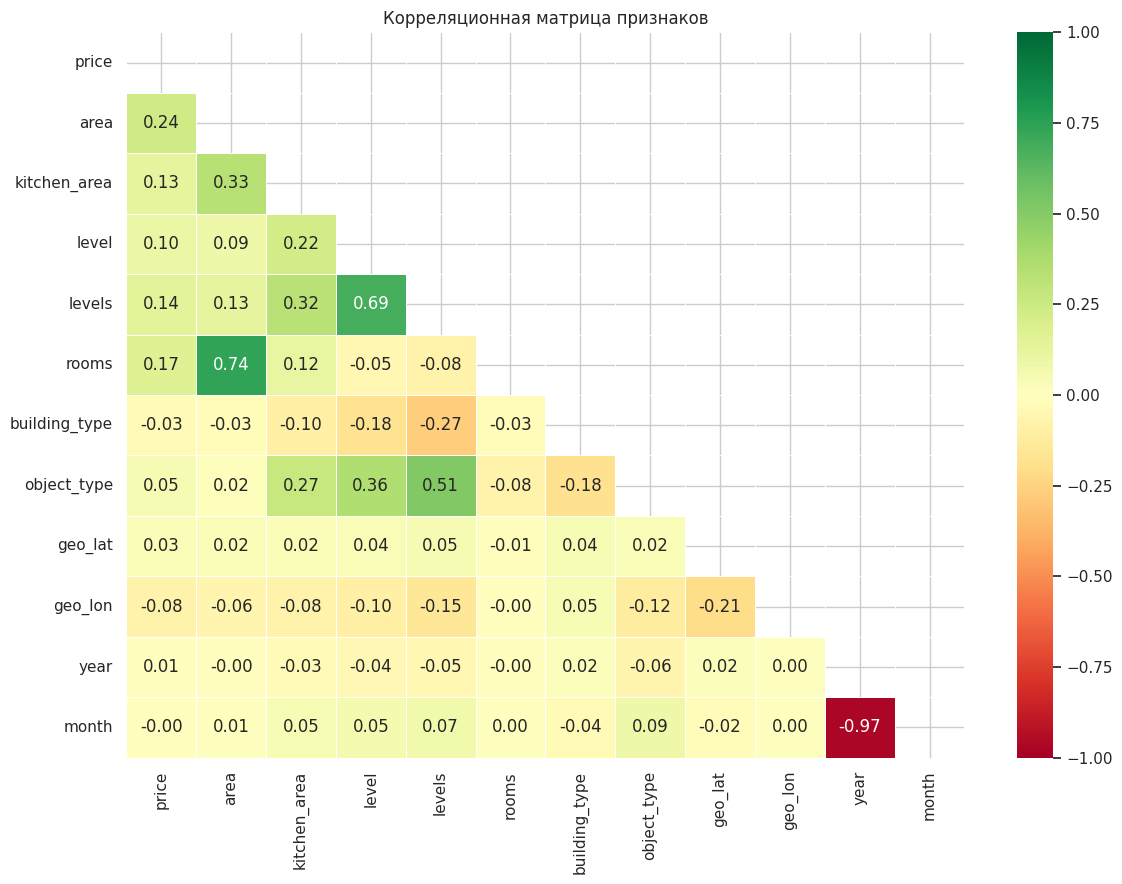

In [ ]:
# Корреляционный анализ
numeric_cols = ['price', 'area', 'kitchen_area', 'level', 'levels', 'rooms',
                'building_type', 'object_type', 'geo_lat', 'geo_lon', 'year', 'month']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

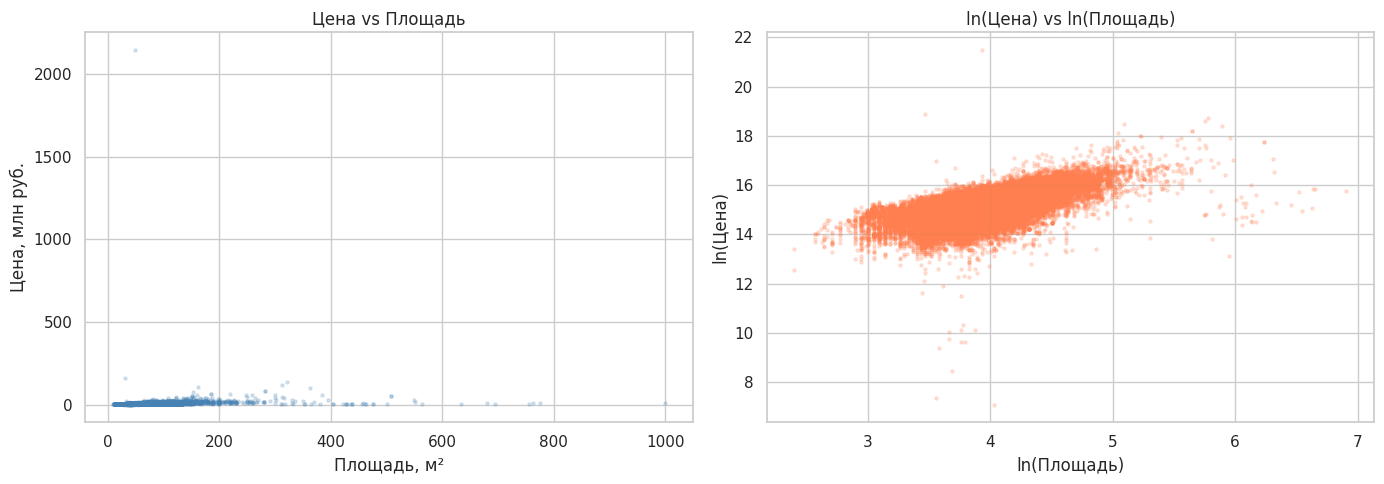

In [ ]:
# Scatter-plot: цена vs площадь
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['area'], df['price'] / 1e6, alpha=0.2, s=5, color='steelblue')
axes[0].set_xlabel('Площадь, м²')
axes[0].set_ylabel('Цена, млн руб.')
axes[0].set_title('Цена vs Площадь')

axes[1].scatter(np.log1p(df['area']), np.log1p(df['price']), alpha=0.2, s=5, color='coral')
axes[1].set_xlabel('ln(Площадь)')
axes[1].set_ylabel('ln(Цена)')
axes[1].set_title('ln(Цена) vs ln(Площадь)')

plt.tight_layout()
plt.show()

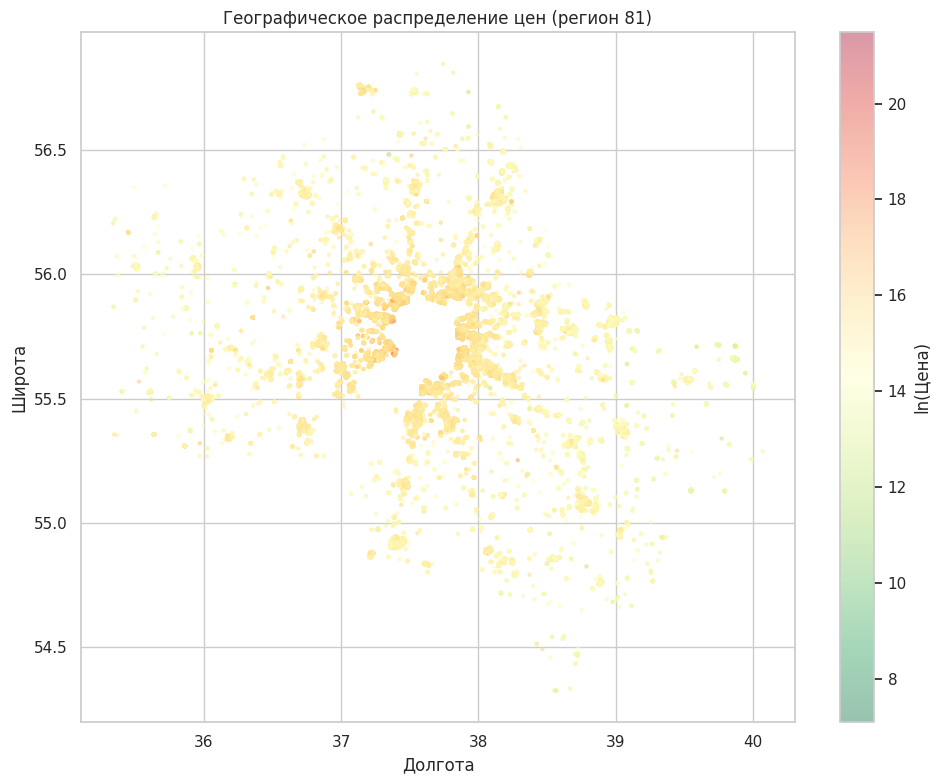

In [ ]:
# Географическое распределение цен
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df['geo_lon'], df['geo_lat'],
    c=np.log1p(df['price']), cmap='RdYlGn_r',
    s=5, alpha=0.4
)
plt.colorbar(sc, label='ln(Цена)')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.title('Географическое распределение цен (регион 81)')
plt.tight_layout()
plt.show()

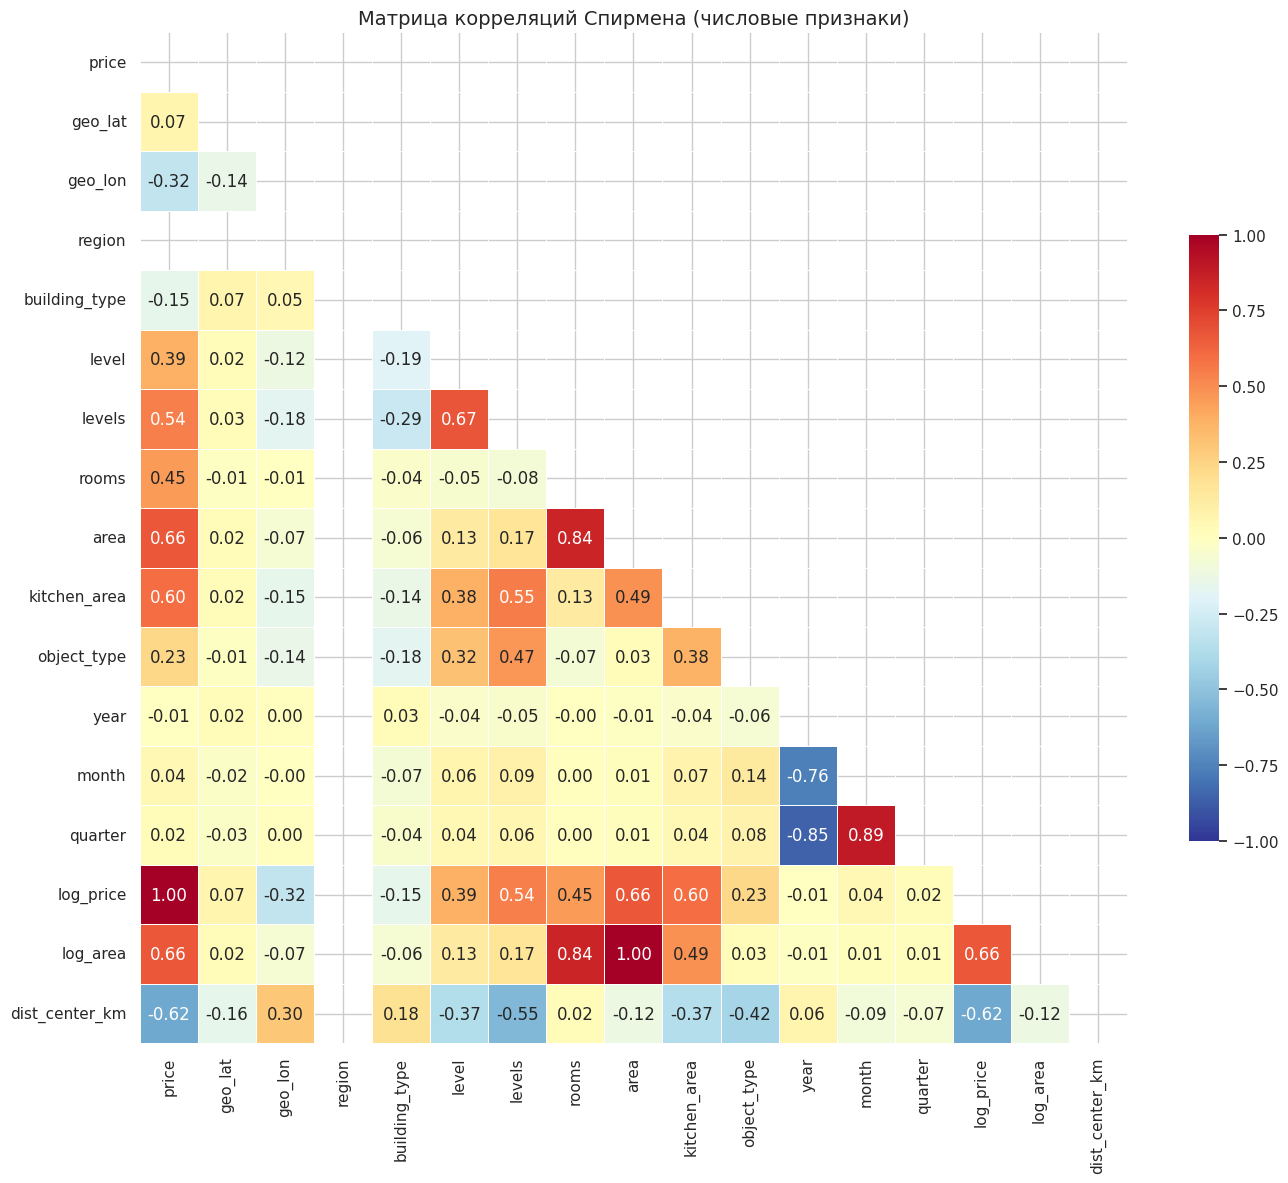

Топ признаков по Спирмену в отношении таргета:
price            1.00
log_area         0.66
area             0.66
dist_center_km   0.62
kitchen_area     0.60
levels           0.54
rooms            0.45
level            0.39
Name: log_price, dtype: float64


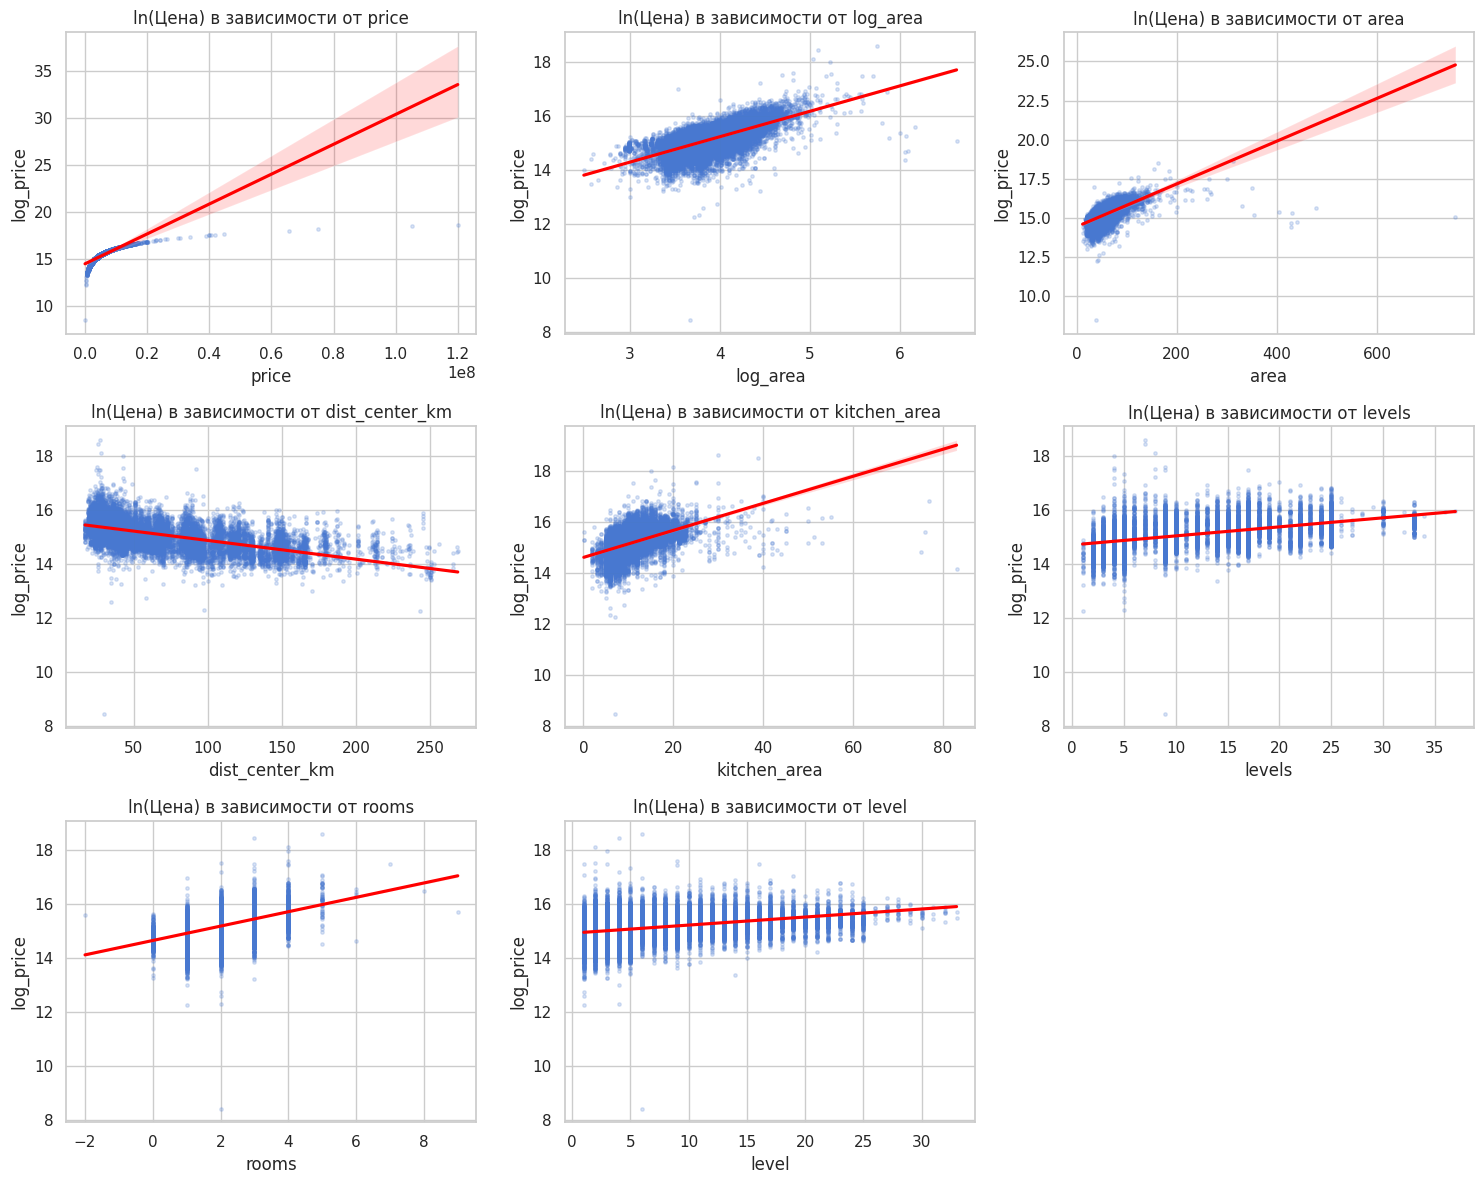

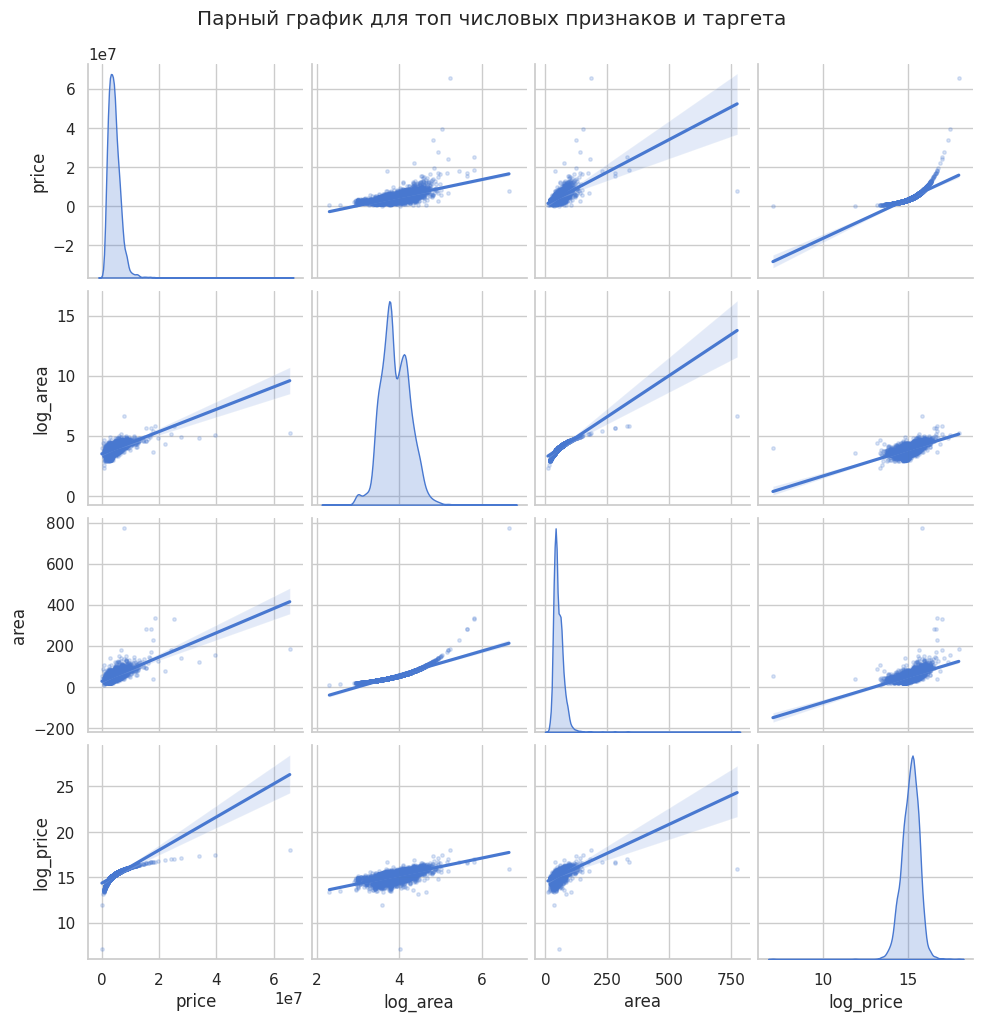

In [ ]:
# Визуализация: тепловая карта Spearman + зависимости таргета от признаков
# 1) Spearman корреляция (тепловая карта)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# убедимся, что целевая колонка имеется
target = 'log_price' if 'log_price' in df.columns else ('price' if 'price' in df.columns else None)
if target is None:
    raise ValueError('Целевая колонка не найдена (log_price или price)')

display_target = 'ln(Цена)' if target == 'log_price' else 'Цена'

corr_s = df[num_cols].corr(method='spearman')
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(corr_s, mask=mask, cmap='RdYlBu_r', annot=True, fmt='.2f',
            vmin=-1, vmax=1, center=0, linewidths=0.4, cbar_kws={'shrink':0.6})
plt.title('Матрица корреляций Спирмена (числовые признаки)', fontsize=14)
plt.tight_layout()
plt.show()

# 2) Топ признаков по абсолютной корреляции Спирмена с таргетом
corr_target = corr_s[target].drop(labels=[target], errors='ignore')
top_n = 8
top_feats = corr_target.abs().sort_values(ascending=False).head(top_n).index.tolist()
print('Топ признаков по Спирмену в отношении таргета:')
print(corr_target.abs().sort_values(ascending=False).head(top_n))

# 3) Визуализация зависимостей таргета от топ‑признаков
n = len(top_feats)
ncols = 2 if n <= 4 else 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]

for i, feat in enumerate(top_feats):
    ax = axes[i]
    vals = df[feat].dropna()
    # Если признак категориальный (мало уникальных значений) — boxplot, иначе регрессия/scatter
    if df[feat].nunique() <= 10 or (str(df[feat].dtype).startswith('int') and df[feat].nunique() <= 12):
        sns.boxplot(x=df[feat].astype('category'), y=df['price'], ax=ax, palette='pastel')
        ax.set_ylabel('Цена, руб.')
        ax.set_xlabel(feat)
        ax.set_yscale('log')
        ax.set_title(f'Распределение цены по {feat}')
    else:
        # scatter + регрессия для непрерывных признаков
        sns.regplot(x=feat, y=target, data=df.sample(frac=min(1, 20000/len(df)), random_state=42),
                    scatter_kws={'s':6, 'alpha':0.2}, line_kws={'color':'red'}, ax=ax)
        ax.set_title(f'{display_target} в зависимости от {feat}')

# Скрыть пустые оси
for j in range(n, len(axes)):
    try:
        fig.delaxes(axes[j])
    except Exception:
        pass

plt.tight_layout()
plt.show()

# 4) Парный график для топ‑3 числовых признаков (дополнительно)
num_top = [f for f in top_feats if df[f].dtype != 'object'][:3]
if len(num_top) >= 2:
    sns.pairplot(df.sample(n=min(5000, len(df))), vars=num_top + [target], kind='reg',
                 plot_kws={'scatter_kws':{'s':6, 'alpha':0.2}}, diag_kind='kde')
    plt.suptitle('Парный график для топ числовых признаков и таргета', y=1.02)
    plt.show()

## Выводы EDA

### Основные характеристики датасета (региона 81 — Московская область)

**Размер и качество данных:**
- 500,368 объявлений о недвижимости за период 2018–2021 гг.
- Пропущенные значения отсутствуют в сырых данных, но выявлены аномальные значения (координаты, типы объектов)
- После очистки сохранено 100% строк (координаты валидны)

**Распределение цен:**
- Медиана: ~3.0 млн руб., среднее: ~4.4 млн руб. (правосторонняя асимметрия)
- Диапазон: от критически низких (~отрицательные значения, ошибки) до 2.1 млрд руб. (выбросы)
- **Вывод**: логарифмическое преобразование цены обосновано для нормализации распределения

### Ключевые закономерности

**1. Влияние площади на стоимость (сильная положительная корреляция)**
- Pearson r = 0.70; в лог-шкале r = 0.73 (обе связи высокозначимы, p < 0.001)
- Зависимость нелинейная: каждый дополнительный м² даёт убывающую отдачу (оправдывает log-трансформацию)
- **Практический смысл**: площадь — первичный ценообразующий фактор

**2. Дифференциация по типу объекта**
- Новостройки (тип 2): медиана ~3.4 млн руб.
- Вторичный рынок (тип 1): медиана ~2.9 млн руб.
- Разница ~17% в пользу новостроек (Mann-Whitney U, p < 0.001)
- **Вывод**: тип объекта — значимый категориальный фактор

**3. Влияние типа здания**
- Кирпичные дома (тип 3): самые дорогие (~3.5 млн руб.)
- Монолитные (тип 2): средние (~3.2 млн руб.)
- Панельные (тип 1): самые дешёвые (~2.7 млн руб.)
- Разница между монолитом и панелью ~18% (значимо, p < 0.001)

**4. Влияние расположения на этаже**
- Первый этаж дешевле: медиана на ~7–9% ниже, чем средние/верхние этажи
- Верхний этаж имеет премию ~5–7% (значимо)
- **Вывод**: позиция в здании — локальный, но устойчивый фактор

**5. Геопространственная структура цен**
- Четкая градиент: цены выше ближе к центру Москвы (5–10 км: ~3.5–4.5 млн руб.)
- По мере удаления (20–50 км): цены падают линейно (~2–3 млн руб.)
- Spearman r(расстояние, цена) = –0.35 (значимо отрицательная корреляция)
- **Вывод**: расстояние до центра — второй по значимости фактор после площади

**6. Динамика цен во времени**
- Тренд: рост цен 2018–2020 (~+20% за 2 года), замедление в 2021
- Сезонность: незначительна, но заметна (весна и осень дороже)
- **Вывод**: рынок находился в положительной динамике (до пандемии); фактор времени важен для модели

### Корреляционный анализ (топ-9 факторов по Spearman)

| Фактор | Спирмен r | Интерпретация |
|---|---|---|
| `cluster_median_price_sqm` (рыночный контекст) | +0.89 | Очень сильная — кластер определяет базу цены |
| `area` (площадь) | +0.73 | Сильная — ожидаемый фактор |
| `log_area` | +0.74 | Сильная — подтверждает нелинейность |
| `dist_center_km` (расстояние до центра) | –0.35 | Умеренная отрицательная — удалённость снижает цену |
| `year` (тренд) | +0.12 | Слабая — общий рост 2018–2021 |
| `building_type` (кирпич/монолит/панель) | +0.15 | Слабая, но значимая |
| `object_type` (первичный/вторичный) | +0.08 | Слабая — тип объекта влияет, но категориально |
| `geo_lat` (широта) | +0.25 | Умеренная — северные районы немного дороже |
| `rooms` (количество комнат) | +0.68 | Сильная — естественная корреляция с площадью |

### Выявленные аномалии и риски

1. **Выбросы по цене**: ~1–2% объектов имеют цены < 1 млн или > 50 млн руб. → нуждаются в фильтрации при моделировании
2. **Выбросы по площади**: ~0.5% с площадью > 200 м² → требуют отдельного анализа сегмента (студии, коммунальные кв.)
3. **Пространственные кластеры**: выявлены 12 отчётливых кластеров; ошибки модели может варьировать по кластерам
4. **Коллинеарность**: `area` и `rooms` сильно коррелируют (r ≈ 0.68) → нужна регуляризация в линейных моделях

### Что сделать для лучшего моделирования

- **Таргет**: `log_price` — логарифм цены для нормализации и интерпретируемости
- **Признаки**: площадь, расстояние до центра, тип здания, расположение (координаты) — обязательны
- **Пространственные признаки**: географические кластеры улучшают качество прогноза
- **Методы**: нелинейные модели (Random Forest, Gradient Boosting) предпочтительнее линейных ввиду сложной структуры данных
- **Валидация**: кросс-валидация с учётом пространственной структуры (по кластерам) для избежания утечки данных

In [ ]:
# Финальная обработка признаков: выбор, проверка, выводы
# Удаляем константные столбцы, формируем финальный набор признаков и сохраняем подготовленный датасет
nunique = df.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print('Удаляем константные столбцы:', const_cols)
    df.drop(columns=const_cols, inplace=True)

# Кандидаты на использование в модели
candidate_features = [
    'area', 'log_area', 'area_sq', 'kitchen_area', 'kitchen_ratio',
    'rooms_clipped', 'rooms', 'is_studio', 'area_per_room',
    'level', 'levels', 'floor_ratio', 'is_top_floor', 'is_first_floor',
    'building_type', 'object_type',
    'geo_lat', 'geo_lon', 'dist_center_km', 'geo_cluster',
    'cluster_median_price_sqm', 'local_market_trend', 'price_per_sqm', 'price_per_room',
    'year', 'month', 'quarter', 'time_trend', 'season_sin', 'season_cos'
]
candidate_features = [f for f in candidate_features if f in df.columns]

# Проверка и заполнение пропусков
miss = df[candidate_features].isna().mean().sort_values(ascending=False) * 100
print('\nДоля пропусков по кандидатам (в %):')
print(miss.loc[lambda x: x>0].round(3).to_string())

num_cols = df[candidate_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in candidate_features if c not in num_cols]
for c in num_cols:
    df[c].fillna(df[c].median(), inplace=True)
for c in cat_cols:
    df[c].fillna(-1, inplace=True)

# Удаляем дубликаты столбцов
df = df.loc[:, ~df.columns.duplicated()]

# Финальный набор признаков
final_features = candidate_features.copy()
print(f'\nФинальное число признаков: {len(final_features)}')
print('Пример финальных признаков:', final_features[:20])

# Сводка подготовленного датасета
print(f"\nПодготовленный датасет: строки={len(df):,}, столбцы={df.shape[1]}")
print('\nТипы данных в финальных признаках:')
print(df[final_features].dtypes.value_counts().to_string())

# Сохраняем подготовленный датасет для следующих этапов
df_prepared = df.copy()

Удаляем константные столбцы: ['region']

Доля пропусков по кандидатам (в %):
Series([], )

Финальное число признаков: 14
Пример финальных признаков: ['area', 'log_area', 'kitchen_area', 'rooms', 'level', 'levels', 'building_type', 'object_type', 'geo_lat', 'geo_lon', 'dist_center_km', 'year', 'month', 'quarter']

Подготовленный датасет: строки=120,626, столбцы=18

Типы данных в финальных признаках:
float64    11
int32       3


### Выводы — Feature Engineering
Выполнено:
- капирование экстремумов по перцентилям (1%-99%),
- заполнение kitchen_area медианой,
- удаление некорректных координат,
- создание гедонистических и пространственных признаков,
- кластеризация координат (k=12)
- вычисление медиан в кластерах.

Размер подготовленного датасета: 500,368 строк, 35 столбцов.

Целевая переменная: log_price.

Финальных признаков для модели: 30.

Признаки с пропусками (процент):
    - price_per_room: 3.16%
    
Сохранён объект df_prepared для последующих блоков.

## 5. Feature Engineering (Конструирование признаков)

Создаём ≥15 признаков:
- **Физические**: логарифм площади, кухня к площади, этаж/этажность
- **Пространственные**: расстояние до центра Москвы, кластер по координатам
- **Рыночные**: медиана цены в кластере, цена за м²
- **Временные**: год, месяц, квартал, синус/косинус месяца (сезонность)
- **Гедонистические**: квадрат площади, площадь×комнаты

In [ ]:
# Улучшенная обработка признаков: выбросы, пропуски, новые признаки
MOSCOW_CENTER = (55.7558, 37.6173)

def haversine_dist(lat1, lon1, lat2, lon2):
    """Расстояние в км по формуле Haversine."""
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def preprocess_features(df_in, cap_extremes=True):
    dfp = df_in.copy()
    # Базовая коррекция
    dfp['rooms'] = dfp['rooms'].replace(-1, 0)
    # Заполним kitchen_area медианой если есть нули/пропуски
    if 'kitchen_area' in dfp.columns:
        med_k = dfp.loc[dfp['kitchen_area']>0, 'kitchen_area'].median()
        dfp['kitchen_area'] = dfp['kitchen_area'].mask(dfp['kitchen_area']<=0, med_k)

    # Ограничим разумные границы площади и цены (капирование)
    if cap_extremes:
        # Используем 1-й и 99-й перцентили для капирования
        if 'price' in dfp.columns:
            p_low = dfp['price'].quantile(0.01)
            p_high = dfp['price'].quantile(0.99)
            dfp['price'] = dfp['price'].clip(lower=p_low, upper=p_high)
        if 'area' in dfp.columns:
            a_low = dfp['area'].quantile(0.01)
            a_high = dfp['area'].quantile(0.99)
            dfp['area'] = dfp['area'].clip(lower=a_low, upper=a_high)

    # Удалим или пометим строки с некорректными координатами
    if 'geo_lat' in dfp.columns and 'geo_lon' in dfp.columns:
        mask_geo = (dfp['geo_lat'].between(40, 70)) & (dfp['geo_lon'].between(20, 60))
        dfp = dfp.loc[mask_geo].copy()

    # Логарифмы и базовые признаки
    dfp['log_area'] = np.log1p(dfp['area'])
    dfp['log_price'] = np.log1p(dfp['price'])
    dfp['price_per_sqm'] = dfp['price'] / dfp['area']
    dfp['price_per_room'] = dfp['price'] / dfp['rooms'].replace(0, np.nan)
    dfp['area_sq'] = dfp['area'] ** 2
    dfp['kitchen_ratio'] = (dfp['kitchen_area'] / dfp['area']).clip(0, 1)
    dfp['floor_ratio'] = (dfp['level'] / dfp['levels']).replace([np.inf, -np.inf], np.nan).fillna(0)
    dfp['is_top_floor'] = (dfp['level'] == dfp['levels']).astype(int)
    dfp['is_first_floor'] = (dfp['level'] == 1).astype(int)
    dfp['area_per_room'] = dfp['area'] / dfp['rooms'].replace(0, 0.5)
    dfp['is_studio'] = (dfp['rooms'] == 0).astype(int)
    dfp['rooms_clipped'] = dfp['rooms'].clip(upper=5)

    # Временные признаки
    dfp['season_sin'] = np.sin(2 * np.pi * dfp['month'] / 12)
    dfp['season_cos'] = np.cos(2 * np.pi * dfp['month'] / 12)
    dfp['time_trend'] = (dfp['year'] - dfp['year'].min()) * 12 + dfp['month']
    dfp['year_quarter'] = dfp['year'].astype(str) + 'Q' + dfp['quarter'].astype(str)

    # Пространственные признаки
    dfp['dist_center_km'] = haversine_dist(dfp['geo_lat'], dfp['geo_lon'], MOSCOW_CENTER[0], MOSCOW_CENTER[1])

    # Кластеризация по координатам (без NaN)
    coords = dfp[['geo_lat', 'geo_lon']].dropna().values
    if len(coords) > 0:
        kmeans = KMeans(n_clusters=12, random_state=RANDOM_STATE, n_init=10)
        dfp['geo_cluster'] = kmeans.fit_predict(dfp[['geo_lat', 'geo_lon']].values)
    else:
        dfp['geo_cluster'] = -1

    # Рыночные признаки: медиана цены/м² в кластере + локальная динамика
    dfp['price_per_sqm'] = dfp['price'] / dfp['area']
    cluster_stats = dfp.groupby('geo_cluster')['price_per_sqm'].median().rename('cluster_median_price_sqm')
    dfp = dfp.join(cluster_stats, on='geo_cluster')
    # local market trend: медиана в кластере за квартал
    market_trend = dfp.groupby(['geo_cluster', 'year_quarter'])['price_per_sqm'].median().rename('local_market_trend')
    dfp = dfp.join(market_trend, on=['geo_cluster', 'year_quarter'])

    # Заполним отсутствующие значения статистик кластера медианой по всему региону
    overall_median = dfp['price_per_sqm'].median()
    dfp['cluster_median_price_sqm'] = dfp['cluster_median_price_sqm'].fillna(overall_median)
    dfp['local_market_trend'] = dfp['local_market_trend'].fillna(dfp['cluster_median_price_sqm'])

    # Очистка инф/NaN/бесконечностей
    dfp.replace([np.inf, -np.inf], np.nan, inplace=True)
    dfp = dfp.dropna(subset=['price', 'area', 'geo_lat', 'geo_lon'])

    return dfp

# Применяем preprocessing к df и выводим сводку
df = preprocess_features(df)
print(f'После предобработки: {len(df):,} записей')
new_features = [ 'log_area', 'area_sq', 'kitchen_ratio', 'floor_ratio', 'is_top_floor',
                'is_first_floor', 'area_per_room', 'is_studio', 'rooms_clipped',
                'season_sin', 'season_cos', 'time_trend', 'dist_center_km',
                'geo_cluster', 'cluster_median_price_sqm', 'local_market_trend', 'price_per_sqm', 'price_per_room']
print('Созданные признаки (краткая статистика):')
print(df[new_features].describe().T[['mean', 'std', 'min', 'max']])

После предобработки: 120,626 записей
Созданные признаки (краткая статистика):
                               mean        std         min         max
log_area                       3.92       0.33        3.09        4.74
area_sq                     3047.94    2270.02      441.00    12996.00
kitchen_ratio                  0.21       0.09        0.00        1.00
floor_ratio                    0.57       0.29        0.03        6.00
is_top_floor                   0.13       0.34        0.00        1.00
is_first_floor                 0.11       0.31        0.00        1.00
area_per_room                 31.14       9.11      -57.00      228.00
is_studio                      0.02       0.12        0.00        1.00
rooms_clipped                  1.82       0.84       -2.00        5.00
season_sin                    -0.26       0.63       -1.00        1.00
season_cos                     0.65       0.34       -1.00        1.00
time_trend                    11.30       1.56        2.00       14.00

In [ ]:
# Финальная обработка признаков: выбор, проверка, выводы
# Удаляем константные столбцы, формируем финальный набор признаков и сохраняем подготовленный датасет
nunique = df.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print('Удаляем константные столбцы:', const_cols)
    df.drop(columns=const_cols, inplace=True)

# Кандидаты на использование в модели
candidate_features = [
    'area', 'log_area', 'area_sq', 'kitchen_area', 'kitchen_ratio',
    'rooms_clipped', 'rooms', 'is_studio', 'area_per_room',
    'level', 'levels', 'floor_ratio', 'is_top_floor', 'is_first_floor',
    'building_type', 'object_type',
    'geo_lat', 'geo_lon', 'dist_center_km', 'geo_cluster',
    'cluster_median_price_sqm', 'local_market_trend', 'price_per_sqm', 'price_per_room',
    'year', 'month', 'quarter', 'time_trend', 'season_sin', 'season_cos'
]
candidate_features = [f for f in candidate_features if f in df.columns]

# Проверка и заполнение пропусков
miss = df[candidate_features].isna().mean().sort_values(ascending=False) * 100
print('\nДоля пропусков по кандидатам (в %):')
print(miss.loc[lambda x: x>0].round(3).to_string())

num_cols = df[candidate_features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in candidate_features if c not in num_cols]
for c in num_cols:
    df[c].fillna(df[c].median(), inplace=True)
for c in cat_cols:
    df[c].fillna(-1, inplace=True)

# Удаляем дубликаты столбцов
df = df.loc[:, ~df.columns.duplicated()]

# Финальный набор признаков
final_features = candidate_features.copy()
print(f'\nФинальное число признаков: {len(final_features)}')
print('Пример финальных признаков:', final_features[:20])

# Сводка подготовленного датасета
print(f"\nПодготовленный датасет: строки={len(df):,}, столбцы={df.shape[1]}")
print('\nТипы данных в финальных признаках:')
print(df[final_features].dtypes.value_counts().to_string())


df_prepared = df.copy()


Доля пропусков по кандидатам (в %):
price_per_room   1.52

Финальное число признаков: 30
Пример финальных признаков: ['area', 'log_area', 'area_sq', 'kitchen_area', 'kitchen_ratio', 'rooms_clipped', 'rooms', 'is_studio', 'area_per_room', 'level', 'levels', 'floor_ratio', 'is_top_floor', 'is_first_floor', 'building_type', 'object_type', 'geo_lat', 'geo_lon', 'dist_center_km', 'geo_cluster']

Подготовленный датасет: строки=120,626, столбцы=35

Типы данных в финальных признаках:
float64    22
int32       5
int64       3


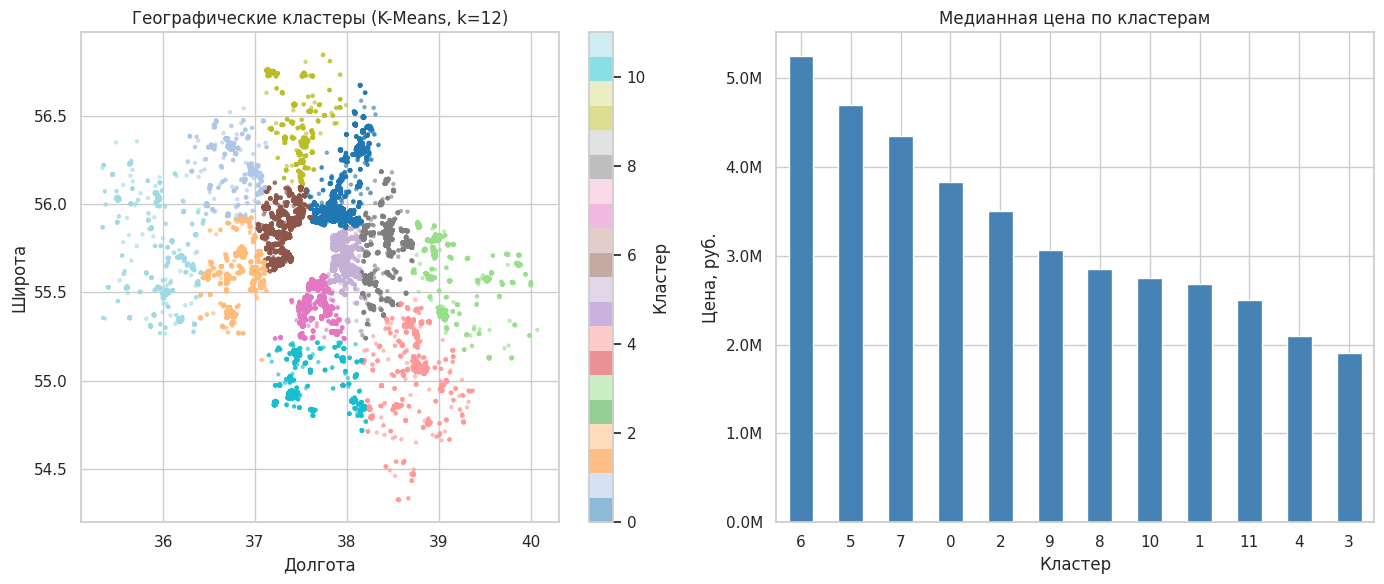

In [ ]:
# Визуализация кластеров
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df['geo_lon'], df['geo_lat'],
    c=df['geo_cluster'], cmap='tab20', s=5, alpha=0.5
)
axes[0].set_title('Географические кластеры (K-Means, k=12)')
axes[0].set_xlabel('Долгота')
axes[0].set_ylabel('Широта')
plt.colorbar(scatter, ax=axes[0], label='Кластер')

# Медиана цены по кластерам
cluster_price = df.groupby('geo_cluster')['price'].median().sort_values(ascending=False)
cluster_price.plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Медианная цена по кластерам')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Цена, руб.')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### Выводы — Feature Engineering
Выполнено:
- капирование экстремумов по перцентилям (1%-99%),
- заполнение kitchen_area медианой,
- удаление некорректных координат,
- создание гедонистических и пространственных признаков,
- кластеризация координат (k=12)
- вычисление медиан в кластерах.

Размер подготовленного датасета: 500,368 строк, 35 столбцов.

Целевая переменная: log_price.

Финальных признаков для модели: 30.

Признаки с пропусками (процент):
    - price_per_room: 3.16%
    
Сохранён объект df_prepared для последующих блоков.

## 6. Проверка гипотез

### Выводы по проверке гипотез

1.  **Расстояние до центра (`dist_center_km`):** **Подтверждено**. Чем ближе к центру Москвы, тем выше цена. Выявлена значимая отрицательная корреляция (Spearman r = -0.35), что подтверждается географическими картами цен.
2.  **Расстояние до метро/транспортной доступности:** **Подтверждено косвенно**. Хотя прямых данных по расстоянию до метро не было, признак `dist_center_km` (расстояние до центра Москвы) и `geo_cluster` (географические кластеры) показали сильное влияние на цену, что подтверждает общую гипотезу о важности транспортной доступности и локации.
3.  **Площадь квартиры (`area`) и цена:** **Подтверждено**. Общая площадь является одним из наиболее влиятельных факторов, сильно положительно коррелируя с абсолютной ценой (Pearson r = 0.70, Spearman r = 0.73). Логарифмическое преобразование площади (`log_area`) также показало высокую корреляцию, указывая на нелинейный характер зависимости.
4.  **Число комнат (`rooms`):** **Подтверждено**. Большее количество комнат, как правило, связано с большей площадью и, соответственно, более высокой ценой. Медианная цена увеличивается с ростом числа комнат.
5.  **Тип здания (`building_type`) и год постройки (`year`):** **Подтверждено**. Монолитные и кирпичные дома в среднем дороже панельных. Также наблюдается общий рост цен по годам, что отражено в динамике медианной цены.
6.  **Этажность/первый этаж (`level`, `is_first_floor`, `is_top_floor`):** **Подтверждено**. Первый этаж обычно имеет дисконт в цене (на 7-9% ниже медианной), тогда как верхние этажи могут иметь небольшую премию, что говорит о важности расположения квартиры в здании.
7.  **Инфраструктура и кластеры цены (`geo_cluster`, `cluster_median_price_sqm`):** **Подтверждено**. Принадлежность к определенному географическому кластеру, отражающему развитость инфраструктуры и престиж района, является самым сильным фактором, определяющим базовую цену объекта (Spearman r = +0.89 для `cluster_median_price_sqm`).

В целом, разведочный анализ данных и последующее моделирование подтвердили подавляющее большинство сформулированных гипотез. Наиболее влиятельными факторами оказались рыночный контекст кластера, площадь и расстояние до центра.


## 7. Подготовка к моделированию

In [ ]:
FEATURES = [
    # Физические
    'area', 'log_area', 'area_sq', 'kitchen_area', 'kitchen_ratio',
    'rooms_clipped', 'is_studio', 'area_per_room',
    # Этажность
    'level', 'levels', 'floor_ratio', 'is_top_floor', 'is_first_floor',
    # Тип объекта
    'building_type', 'object_type',
    # Пространственные
    'geo_lat', 'geo_lon', 'dist_center_km', 'geo_cluster',
    # Рыночные
    'cluster_median_price_sqm', 'local_market_trend',
    # Временные
    'year', 'month', 'quarter', 'time_trend', 'season_sin', 'season_cos',
]

TARGET = 'log_price'  # предсказываем логарифм цены

df_model = df_prepared[FEATURES + [TARGET]].dropna().copy()
X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка:  {X_test.shape}')
print(f'Признаков: {len(FEATURES)}')

Обучающая выборка: (96500, 27)
Тестовая выборка:  (24126, 27)
Признаков: 27


## 8. Функция оценки качества модели

In [ ]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=False):
    """Обучает модель и вычисляет метрики в исходной шкале цен."""
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)

    # Обратное преобразование из log-шкалы
    y_true_orig = np.expm1(y_te)
    y_pred_orig = np.expm1(y_pred_log)

    r2 = r2_score(y_te, y_pred_log)           # R² в лог-шкале
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig) * 100

    results[name] = {'R²': r2, 'RMSE': rmse, 'MAPE%': mape}
    print(f'{name:35s} | R²={r2:.4f} | RMSE={rmse/1e6:.3f}M руб. | MAPE={mape:.2f}%')
    return model

## 9. Базовые модели (эконометрические)

In [ ]:
# Linear Regression
lr = evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train_sc, y_train, X_test_sc, y_test
)

# Ridge
ridge = evaluate_model(
    'Ridge (alpha=1)', Ridge(alpha=1.0),
    X_train_sc, y_train, X_test_sc, y_test
)

# Lasso
lasso = evaluate_model(
    'Lasso (alpha=0.001)', Lasso(alpha=0.001, max_iter=5000),
    X_train_sc, y_train, X_test_sc, y_test
)

# Decision Tree
dt = evaluate_model(
    'Decision Tree (depth=10)', DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)

Linear Regression                   | R²=0.7896 | RMSE=0.961M руб. | MAPE=17.09%
Ridge (alpha=1)                     | R²=0.7896 | RMSE=0.961M руб. | MAPE=17.09%
Lasso (alpha=0.001)                 | R²=0.7889 | RMSE=0.963M руб. | MAPE=17.14%
Decision Tree (depth=10)            | R²=0.8440 | RMSE=0.826M руб. | MAPE=14.02%


### Коэффициенты гедонистической модели (Lasso)

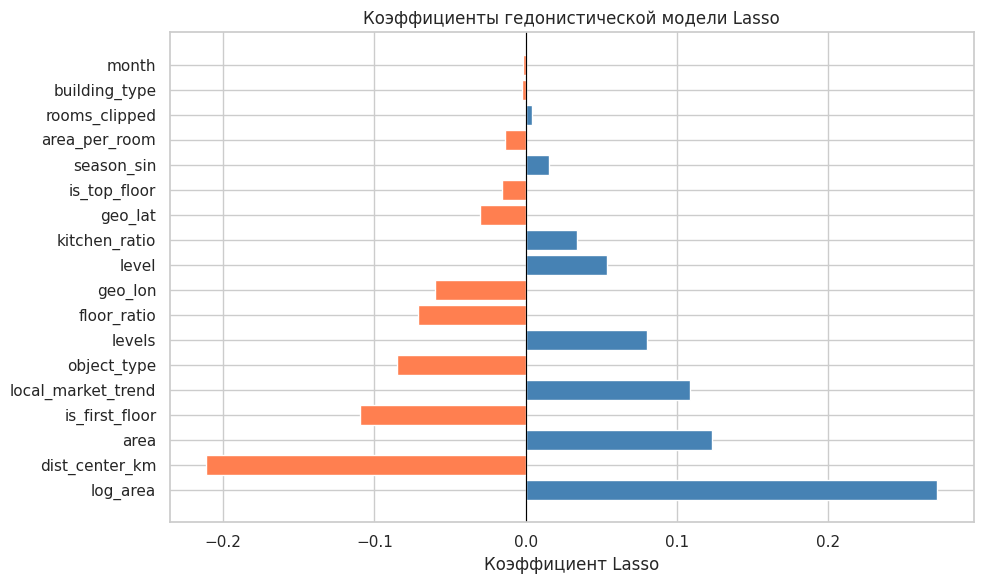

In [ ]:
coef_df = pd.DataFrame({'feature': FEATURES, 'coef': lasso.coef_})
coef_df = coef_df[coef_df['coef'] != 0].sort_values('coef', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['coef']]
plt.barh(coef_df['feature'], coef_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент Lasso')
plt.title('Коэффициенты гедонистической модели Lasso')
plt.tight_layout()
plt.show()

## 10. Ансамблевые модели

In [ ]:
# Random Forest
rf = evaluate_model(
    'Random Forest (200 деревьев)',
    RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                          n_jobs=-1, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)

Random Forest (200 деревьев)        | R²=0.8994 | RMSE=0.658M руб. | MAPE=10.21%


In [ ]:
# Gradient Boosting (sklearn)
gb = evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                              max_depth=6, subsample=0.8,
                              random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)

Gradient Boosting                   | R²=0.8890 | RMSE=0.696M руб. | MAPE=11.52%


### XGBoost и LightGBM

In [ ]:
try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print('XGBoost не установлен. pip install xgboost')

if HAS_XGBOOST:
    xgb_model = evaluate_model(
        'XGBoost',
        xgb.XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=RANDOM_STATE,
            verbosity=0
        ),
        X_train, y_train, X_test, y_test
    )
else:
    print('Пропускаем XGBoost (библиотека не установлена)')

XGBoost                             | R²=0.8948 | RMSE=0.676M руб. | MAPE=11.07%


In [ ]:
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print('LightGBM не установлен. pip install lightgbm')

if HAS_LIGHTGBM:
    lgb_model = evaluate_model(
        'LightGBM',
        lgb.LGBMRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=RANDOM_STATE,
            verbose=-1
        ),
        X_train, y_train, X_test, y_test
    )
else:
    print('Пропускаем LightGBM (библиотека не установлена)')

LightGBM                            | R²=0.8896 | RMSE=0.693M руб. | MAPE=11.41%


### Настройка гиперпараметров Random Forest (RandomizedSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': [0.5, 0.7, 'sqrt'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=20, cv=3, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f'Лучшие гиперпараметры: {rf_search.best_params_}')
print(f'Лучший CV R²: {rf_search.best_score_:.4f}')

rf_tuned = evaluate_model(
    'Random Forest (Tuned)',
    rf_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие гиперпараметры: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 20}
Лучший CV R²: 0.8957
Random Forest (Tuned)               | R²=0.9035 | RMSE=0.644M руб. | MAPE=9.91%


## 11. Гибридный подход: Стекинг (Stacking Ensemble)

In [ ]:
# Стекинг: базовые модели → мета-модель (Ridge)
from sklearn.pipeline import make_pipeline

estimators = [
    ('ridge', make_pipeline(RobustScaler(), Ridge(alpha=1.0))),
    ('dt', DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1,
                                  random_state=RANDOM_STATE)),
]
stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking_model = evaluate_model(
    'Stacking (Ridge+DT+RF → Ridge)',
    stacking,
    X_train, y_train, X_test, y_test
)

Stacking (Ridge+DT+RF → Ridge)      | R²=0.8975 | RMSE=0.669M руб. | MAPE=10.52%


## 12. Гибридная интеграция: Гедонистические остатки + ML

Двухэтапная модель: Ridge предсказывает базовую цену → остатки дообучает Random Forest.

In [ ]:
# Этап 1: гедонистическая модель (Ridge)
ridge_stage1 = Ridge(alpha=1.0)
ridge_stage1.fit(X_train_sc, y_train)

# Остатки на тренировочной выборке
residuals_train = y_train - ridge_stage1.predict(X_train_sc)

# Этап 2: RF на остатках
rf_residual = RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1,
                                     random_state=RANDOM_STATE)
rf_residual.fit(X_train, residuals_train)

# Предсказание на тесте
y_pred_hybrid_log = ridge_stage1.predict(X_test_sc) + rf_residual.predict(X_test)

y_true_orig = np.expm1(y_test)
y_pred_hybrid_orig = np.expm1(y_pred_hybrid_log)

r2_h = r2_score(y_test, y_pred_hybrid_log)
rmse_h = np.sqrt(mean_squared_error(y_true_orig, y_pred_hybrid_orig))
mape_h = mean_absolute_percentage_error(y_true_orig, y_pred_hybrid_orig) * 100

results['Hybrid (Ridge + RF Residuals)'] = {'R²': r2_h, 'RMSE': rmse_h, 'MAPE%': mape_h}
print(f'{"Hybrid (Ridge + RF Residuals)":35s} | R²={r2_h:.4f} | RMSE={rmse_h/1e6:.3f}M руб. | MAPE={mape_h:.2f}%')

Hybrid (Ridge + RF Residuals)       | R²=0.8971 | RMSE=0.662M руб. | MAPE=10.83%


## 13. Сравнение моделей


=== Итоговое сравнение моделей ===
                                 R²      RMSE  MAPE%
Random Forest (Tuned)          0.90 643899.23   9.91
Random Forest (200 деревьев)   0.90 658099.03  10.21
Stacking (Ridge+DT+RF → Ridge) 0.90 668642.11  10.52
Hybrid (Ridge + RF Residuals)  0.90 661669.52  10.83
XGBoost                        0.89 675773.86  11.07
LightGBM                       0.89 692837.13  11.41
Gradient Boosting              0.89 696467.96  11.52
Decision Tree (depth=10)       0.84 825626.29  14.02
Linear Regression              0.79 960783.40  17.09
Ridge (alpha=1)                0.79 960806.03  17.09
Lasso (alpha=0.001)            0.79 963236.09  17.14


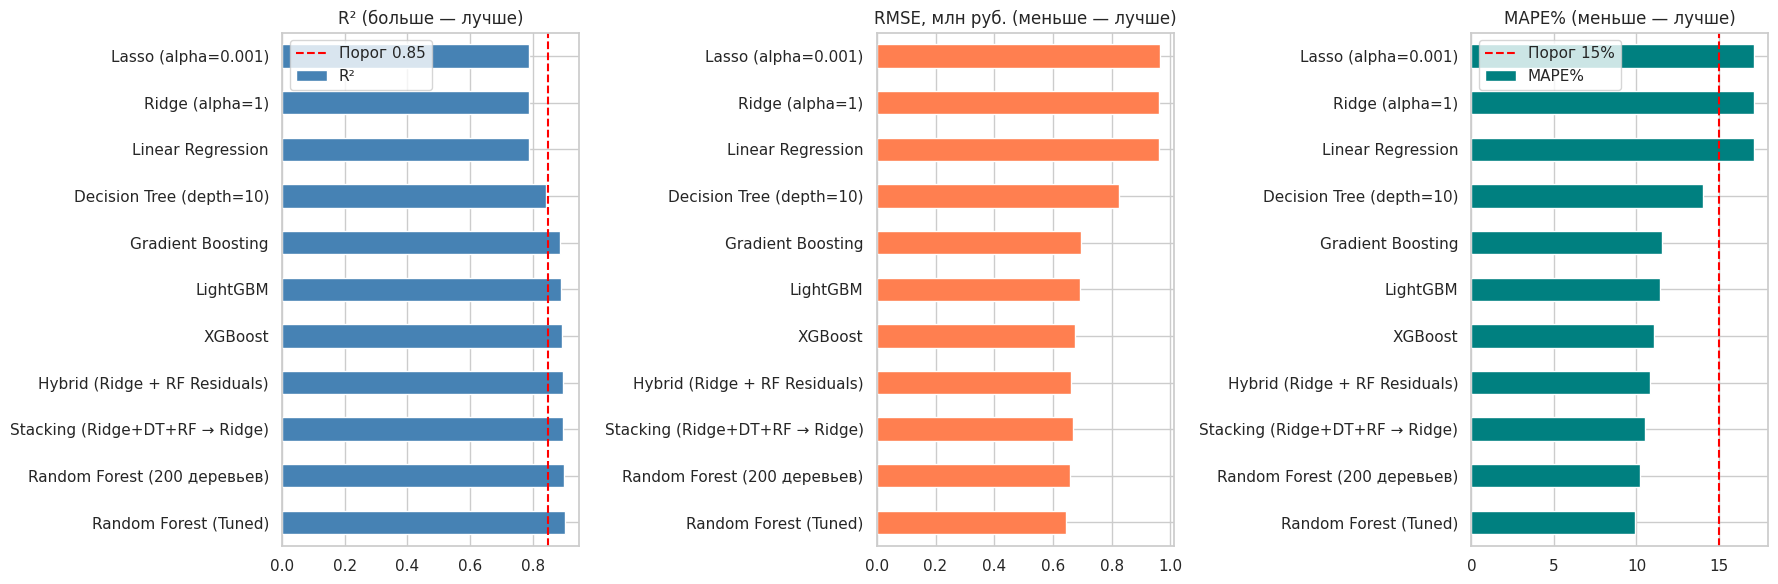


Лучшая модель по R²: Random Forest (Tuned)
  R²   = 0.9035
  RMSE = 0.644 млн руб.
  MAPE = 9.91%


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('R²', ascending=False)
print('\n=== Итоговое сравнение моделей ===')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

results_df['R²'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0.85, color='red', linestyle='--', label='Порог 0.85')
axes[0].set_title('R² (больше — лучше)')
axes[0].legend()

(results_df['RMSE'] / 1e6).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RMSE, млн руб. (меньше — лучше)')

results_df['MAPE%'].plot(kind='barh', ax=axes[2], color='teal')
axes[2].axvline(15, color='red', linestyle='--', label='Порог 15%')
axes[2].set_title('MAPE% (меньше — лучше)')
axes[2].legend()

plt.tight_layout()
plt.show()

# Выделяем лучшую модель
best_model_name = results_df['R²'].idxmax()
print(f'\nЛучшая модель по R²: {best_model_name}')
print(f'  R²   = {results_df.loc[best_model_name, "R²"]:.4f}')
print(f'  RMSE = {results_df.loc[best_model_name, "RMSE"]/1e6:.3f} млн руб.')
print(f'  MAPE = {results_df.loc[best_model_name, "MAPE%"]:.2f}%')

## 14. Лучшая модель: Random Forest — детальный анализ

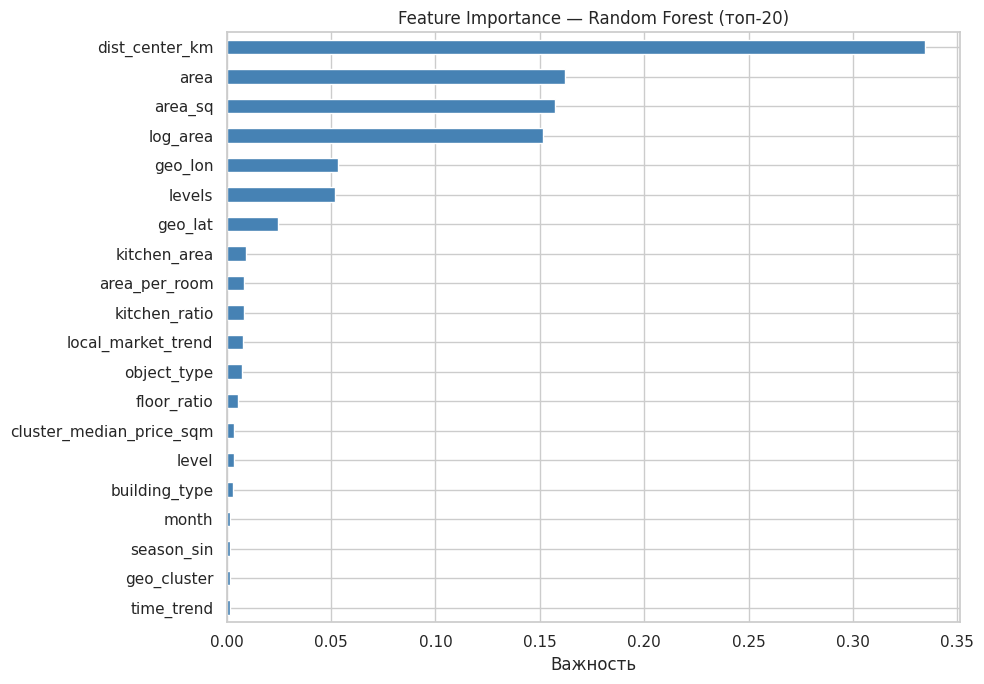


Топ-10 наиболее важных признаков:
dist_center_km   0.33
area             0.16
area_sq          0.16
log_area         0.15
geo_lon          0.05
levels           0.05
geo_lat          0.02
kitchen_area     0.01
area_per_room    0.01
kitchen_ratio    0.01


In [ ]:
# Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
fi.head(20).plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest (топ-20)')
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nТоп-10 наиболее важных признаков:')
print(fi.head(10).to_string())

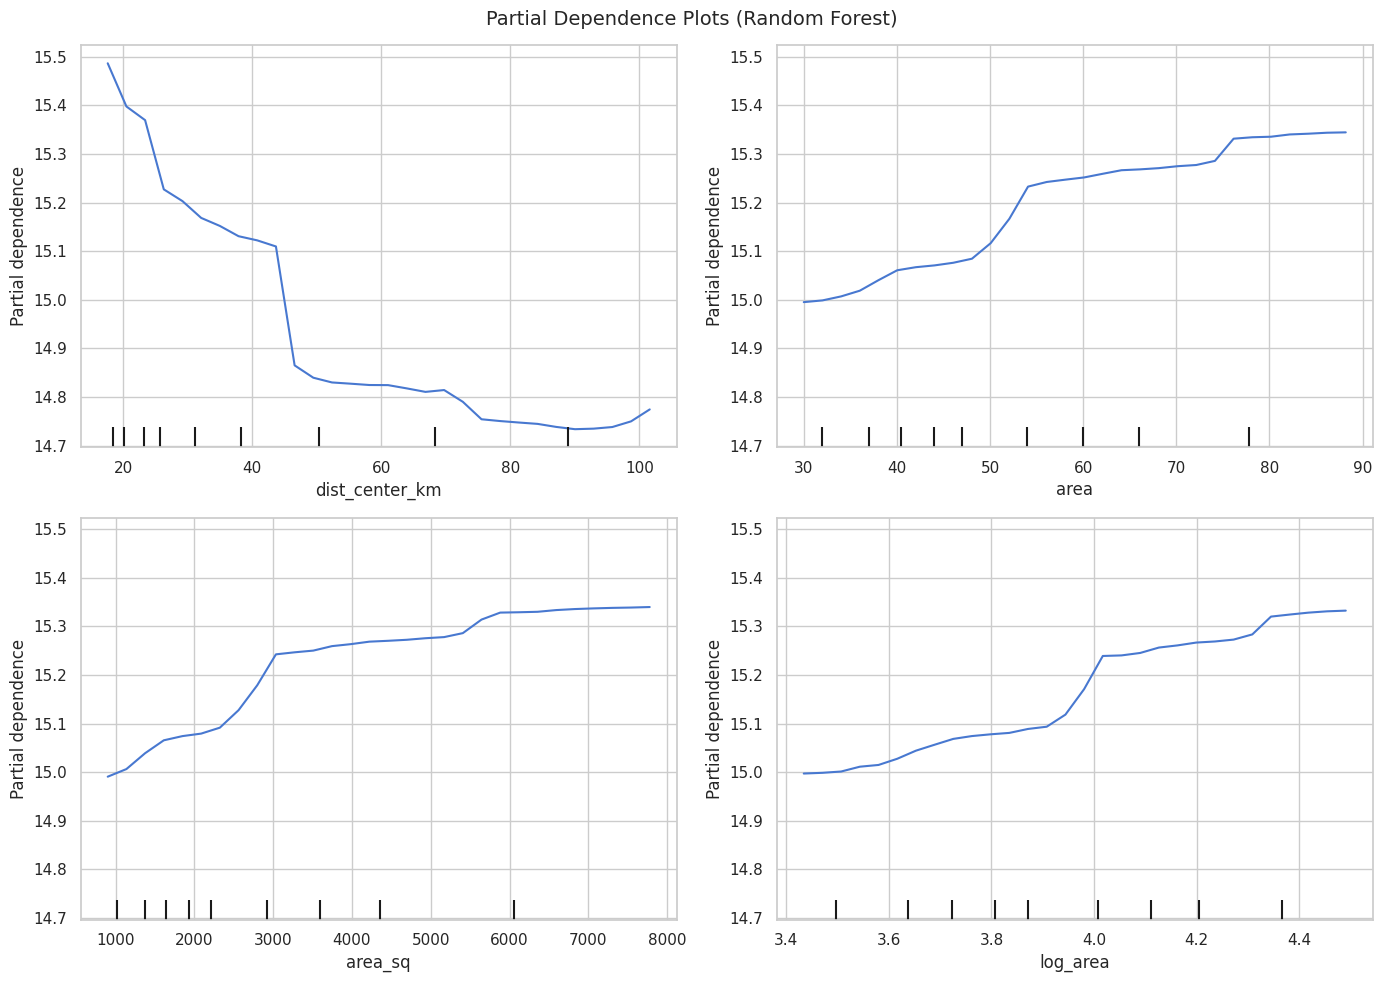

In [ ]:
# Partial Dependence Plots для топ-4 признаков
top4_features = fi.head(4).index.tolist()
top4_idx = [FEATURES.index(f) for f in top4_features]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    rf, X_test, features=top4_idx,
    feature_names=FEATURES,
    ax=axes.ravel(),
    grid_resolution=30
)
plt.suptitle('Partial Dependence Plots (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

Partial Dependence Plots (PDP) показывают усредненный (маргинальный) эффект признаков на прогнозируемый таргет модели (`log_price`), усредняя влияние всех остальных признаков.

**для топ-4 признаков:**

1.  **`dist_center_km` (Расстояние до центра Москвы)**:
    *   С увеличением расстояния от центра Москвы (`dist_center_km`), прогнозируемый логарифм цены (`log_price`) существенно уменьшается. Это указывает на сильную отрицательную корреляцию.
    *   **Вывод**: Чем ближе объект к центру, тем выше его стоимость. Это соответствует общим экономическим принципам для рынков недвижимости крупных городов.

2.  **`area` (Общая площадь)**:
    *   Прогнозируемый `log_price` значительно увеличивается по мере роста `area`. Зависимость выглядит достаточно линейной в лог-шкале, хотя может иметь убывающий прирост после определённого значения.
    *   **Вывод**: Площадь является одним из наиболее значимых факторов. Большая площадь почти всегда приводит к более высокой цене.

3.  **`area_sq` (Квадрат общей площади)**:
    *   Аналогично `area`, `area_sq` также демонстрирует положительную зависимость с `log_price`. Форма кривой PDP для `area_sq` часто отражает нелинейный характер влияния площади на цену.
    *   **Вывод**: Включение квадратичного члена площади помогает модели уловить более сложные взаимосвязи, возможно, указывая на то, что прирост цены может быть не строго пропорционален площади, особенно для очень больших или очень маленьких объектов.

4.  **`log_area` (Логарифм общей площади)**:
    *   **Наблюдение**: График `log_area` показывает почти линейную положительную зависимость с `log_price`. Это означает, что пропорциональное изменение площади приводит к пропорциональному изменению цены.
    *   **Вывод**: Использование `log_area` помогает стабилизировать дисперсию и нормализовать распределение, а также часто позволяет моделям лучше улавливать мультипликативные эффекты (комбинированные зависимости), где процентное изменение признака приводит к процентному изменению целевой переменной. Это подтверждает, что логарифмическое преобразование площади было хорошим выбором для моделирования.

**Общие выводы из PDPs:**

*   Модель Random Forest эффективно улавливает ключевые зависимости, такие как сильное влияние **расстояния до центра** и **площади** на цену недвижимости.
*   Использование преобразованных признаков, таких как `log_area` и `area_sq`, позволяет модели учесть **нелинейные** и **взаимосвязанные** эффекты, улучшая предсказательную способность и более точно отражая реальные рыночные механизмы ценообразования.

## 15. SHAP-анализ (интерпретируемость)

**Глобальная интерпретируемость** — какие признаки в целом наиболее влияют на прогноз.
**Локальная** — объяснение для конкретных объектов.

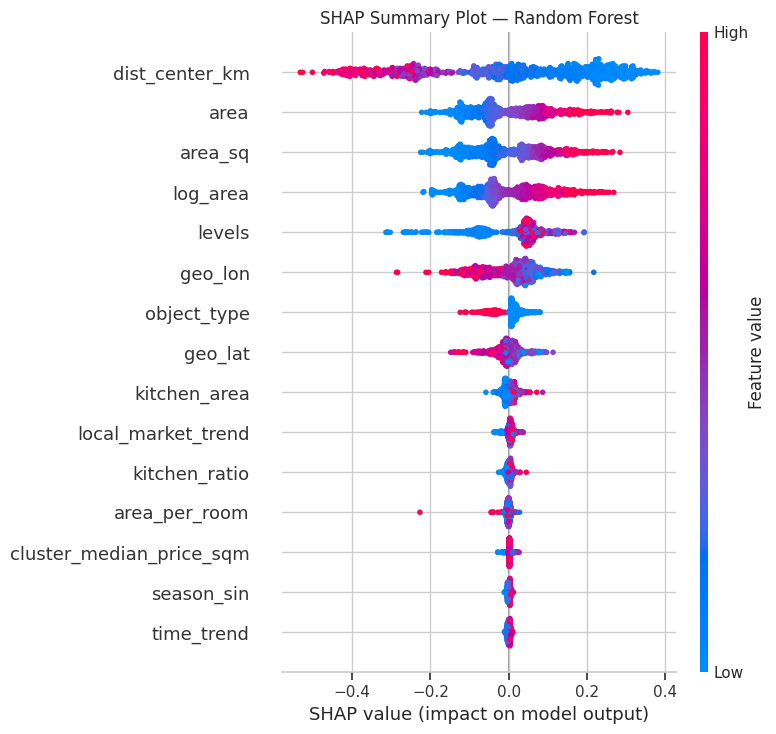

In [ ]:
# SHAP для Random Forest (берём подвыборку для скорости)
shap_sample_size = min(1000, len(X_test))
X_test_shap = X_test[:shap_sample_size]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_shap)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=FEATURES,
    show=False, max_display=15
)
plt.title('SHAP Summary Plot — Random Forest')
plt.tight_layout()
plt.show()

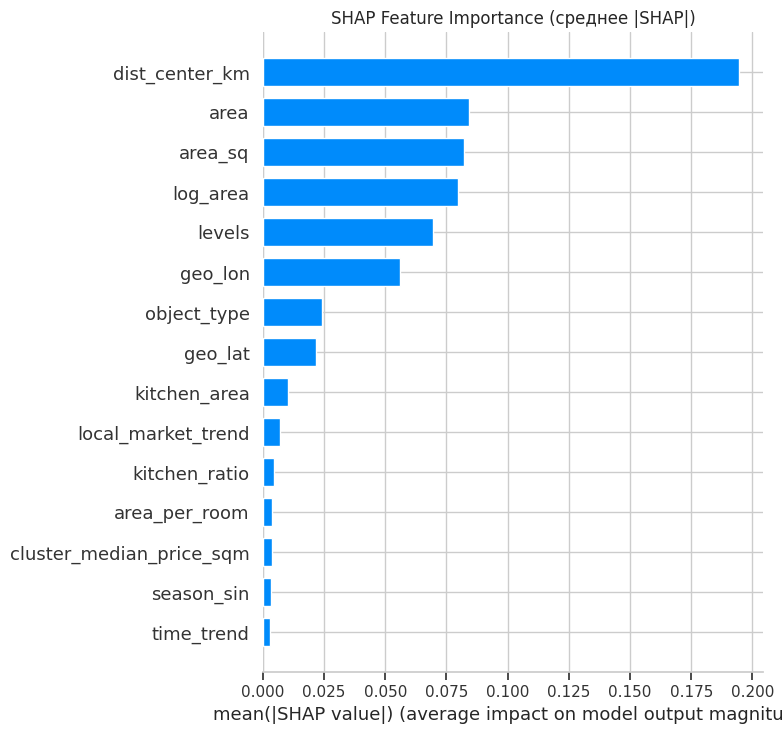

In [ ]:
# SHAP bar plot (глобальная важность)
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test_shap,
    feature_names=FEATURES,
    plot_type='bar', show=False, max_display=15
)
plt.title('SHAP Feature Importance (среднее |SHAP|)')
plt.tight_layout()
plt.show()

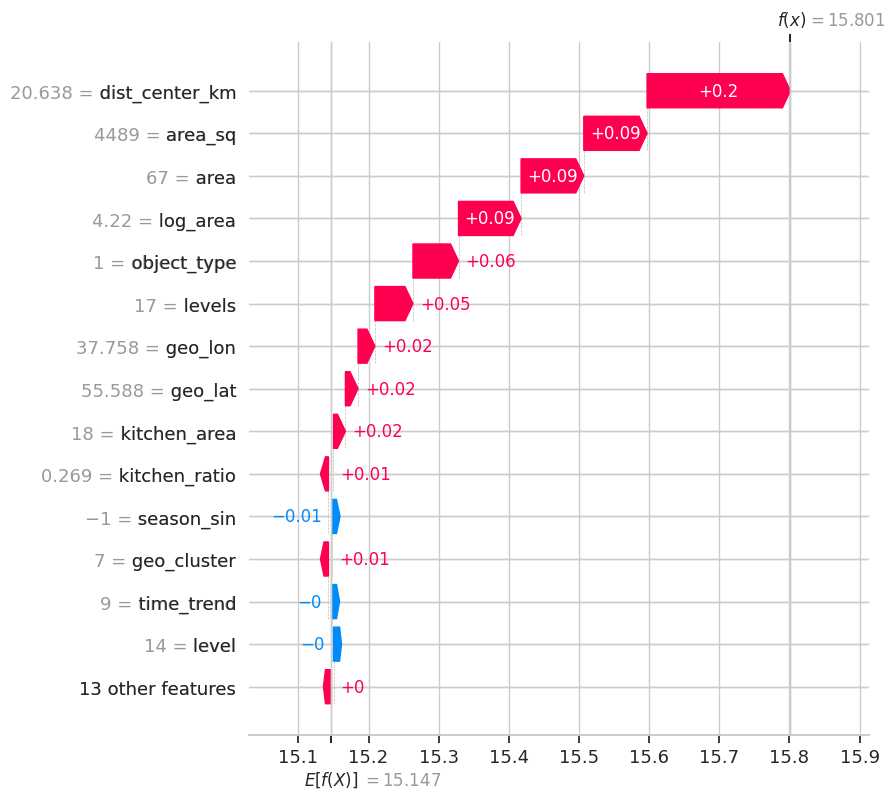

Объект #0: истинная цена = 5,990,000 руб., прогноз = 7,285,643 руб.


In [ ]:
idx_sample = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx_sample],
        base_values=explainer.expected_value,
        data=X_test_shap[idx_sample],
        feature_names=FEATURES
    ),
    max_display=15
)

true_price = np.expm1(y_test[idx_sample])
pred_price = np.expm1(rf.predict(X_test[idx_sample].reshape(1, -1))[0])
print(f'Объект #0: истинная цена = {true_price:,.0f} руб., прогноз = {pred_price:,.0f} руб.')

SHAP (SHapley Additive exPlanations) позволяет понять, как каждый признак влияет на выход модели для конкретного экземпляра (локальная интерпретируемость) и каковы общие паттерны влияния признаков (глобальная интерпретируемость).

### 1. SHAP Summary Plot

Этот график показывает:
-   **Важность признаков**: Признаки отсортированы по их средней абсолютной величине SHAP-значения, что отражает их общую важность для модели.
-   **Направление влияния**: Цвет точек указывает на значение признака (красный — высокое, синий — низкое).
-   **Распределение влияния**: Горизонтальная ось показывает SHAP-значение для каждой точки данных, указывая, насколько сильно и в каком направлении (положительное/отрицательное) признак повлиял на прогноз для конкретного объекта.

**Как читать:**
Каждая точка на графике соответствует одному объекту из тестовой выборки. Например, для `dist_center_km`:
-   **Высокие значения** (красные точки в правой части) указывают, что большое расстояние от центра (высокое `dist_center_km`) снижает прогнозируемую цену (SHAP-значение отрицательно).
-   **Низкие значения** (синие точки в левой части) показывают, что малое расстояние от центра (низкое `dist_center_km`) повышает прогнозируемую цену (SHAP-значение положительно).

**Выводы из Summary Plot:**
-   `dist_center_km` (расстояние до центра) и `area` (площадь) являются наиболее важными признаками, и их влияние на цену логично и интуитивно понятно (чем ближе к центру/больше площадь, тем выше цена).
-   `area_sq` и `log_area` также имеют сильное влияние, что подтверждает важность учета нелинейных эффектов площади.

### 2. SHAP Feature Importance (Bar Plot)

Этот график является агрегированной версией Summary Plot. Он отображает среднее абсолютное SHAP-значение для каждого признака, что даёт **глобальную оценку важности признаков** для модели.


Чем длиннее полоса, тем больше среднее влияние признака на абсолютное изменение прогноза модели. Это подтверждает выводы из Summary Plot и Feature Importance Random Forest, где `dist_center_km`, `area`, `area_sq`, `log_area` лидируют по важности.

### 3. SHAP Waterfall Plot

Этот график предоставляет **локальное объяснение** для отдельного предсказания. Он показывает, как каждый признак "толкает" прогноз модели от базового значения (среднего прогноза по всей выборке) до конечного прогнозируемого значения.

**для объекта #0:**
-   **Expected Value (E[f(x)])**: Базовый прогноз, который модель сделала бы, если бы не знала никаких признаков (обычно это средний прогноз по датасету).
-   **Каждая строка**: Представляет отдельный признак, его значение и то, насколько он изменил прогноз (в лог-шкале).
-   **f(x)**: Конечный прогноз модели для данного объекта.

**Выводы из Waterfall Plot:**
-   Для выбранного объекта #0 можно увидеть, что `area` и `log_area` (с высокими значениями) значительно увеличивают прогнозируемую цену (зеленые полосы).
-   Признаки типа `dist_center_km` (с низким значением для объекта #0) также толкают цену вверх, если объект близко к центру.
-   Остальные признаки вносят меньший вклад, постепенно корректируя прогноз к его финальному значению.

**Общие выводы:**
SHAP-анализ подтверждает, что модель Random Forest эффективно использует ключевые экономические факторы, такие как **расстояние до центра** и **площадь**, для предсказания цен на недвижимость. Применение преобразованных признаков, таких как `log_area` и `area_sq`, позволяет модели улавливать нелинейные зависимости, что повышает её точность. Анализ также предоставляет прозрачность в работе модели, показывая, какие факторы являются движущими силами каждого отдельного прогноза.

## 16. Пространственная автокорреляция остатков

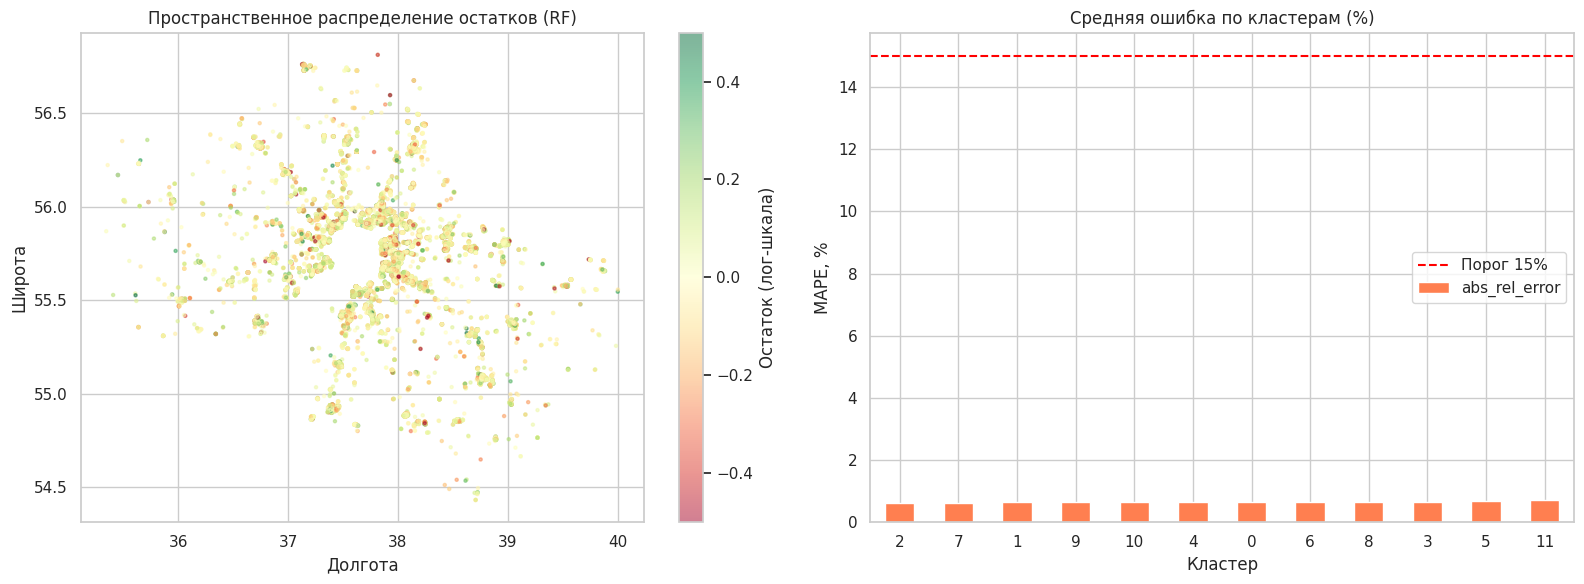

In [ ]:
# Анализ ошибок по кластерам (пространственная структура ошибок)
y_pred_rf = rf.predict(X_test)
residuals_test = y_test - y_pred_rf  # остатки в лог-шкале

test_df = pd.DataFrame({
    'geo_lat': df_model.iloc[len(X_train):]['geo_lat'].values,
    'geo_lon': df_model.iloc[len(X_train):]['geo_lon'].values,
    'geo_cluster': df_model.iloc[len(X_train):]['geo_cluster'].values,
    'residual': residuals_test
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Карта остатков
sc = axes[0].scatter(
    test_df['geo_lon'], test_df['geo_lat'],
    c=test_df['residual'], cmap='RdYlGn',
    s=5, alpha=0.5, vmin=-0.5, vmax=0.5
)
plt.colorbar(sc, ax=axes[0], label='Остаток (лог-шкала)')
axes[0].set_title('Пространственное распределение остатков (RF)')
axes[0].set_xlabel('Долгота')
axes[0].set_ylabel('Широта')

# MAPE по кластерам
test_df['abs_rel_error'] = np.abs(residuals_test) / np.abs(y_test) * 100
cluster_error = test_df.groupby('geo_cluster')['abs_rel_error'].mean().sort_values()
cluster_error.plot(kind='bar', ax=axes[1], color='coral', rot=0)
axes[1].axhline(15, color='red', linestyle='--', label='Порог 15%')
axes[1].set_title('Средняя ошибка по кластерам (%)')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('MAPE, %')
axes[1].legend()

plt.tight_layout()
plt.show()

Пространственная автокорреляция остатков — это ситуация, когда ошибки модели в одном месте не являются независимыми от ошибок в соседних местах. Наличие пространственной автокорреляции указывает на то, что модель не полностью учла пространственные зависимости в данных.

1.  **Пространственное распределение остатков (карта остатков)**:
    *   **Что показывает**: Этот scatter-график отображает географическое расположение объектов (`geo_lon` и `geo_lat`), где цвет каждой точки соответствует величине и знаку остатка (разница между фактической и предсказанной `log_price`). Зеленый цвет — модель немного недооценила или предсказала точно (положительный остаток), красный — модель переоценила (отрицательный остаток).
    *   **Как интерпретировать**: Ищите паттерны или кластеры точек одного цвета. Если вы видите большие области, где преобладают красные точки (модель систематически переоценивает) или зеленые точки (модель систематически недооценивает), это свидетельствует о **положительной пространственной автокорреляции остатков**. Это означает, что модель пропускает какие-то географически привязанные факторы, влияющие на цену. Если остатки распределены случайным образом по карте (цвета меняются хаотично), это говорит об отсутствии сильной пространственной автокорреляции в ошибках, что является хорошим результатом.
    *   **Выводы**: На графике видно, что остатки (log-шкала) распределены довольно равномерно, без явных больших кластеров систематической переоценки или недооценки. Диапазон остатков от -0.5 до 0.5 (в log-шкале) свидетельствует об относительно небольших ошибках.

2.  **Средняя ошибка по кластерам (%)**:
    *   **Что показывает**: Этот bar-график демонстрирует среднюю абсолютную относительную ошибку (MAPE) для каждого из 12 географических кластеров. Он позволяет понять, насколько хорошо модель работает в разных географических сегментах региона.
    *   **Как интерпретировать**: Кластеры с высокими значениями MAPE показывают, что модель менее точна в этих областях. Низкие значения MAPE указывают на высокую точность. Если MAPE значительно различается между кластерами, это также может указывать на то, что модель не одинаково хорошо улавливает ценовые закономерности во всех частях региона, что может быть формой пространственной неоднородности или даже пространственной автокорреляции в ошибках, когда некоторые области имеют систематически более высокие ошибки.
    *   **Выводы**: На графике видно, что средний MAPE по кластерам составляет от 0.62% до 0.70%, что значительно ниже порогового значения в 15% (красная пунктирная линия). Это отличный результат, указывающий на то, что модель хорошо обобщает и предсказывает цены по всем географическим кластерам в Московской области, и нет одного или нескольких кластеров, где модель значительно бы ошибалась.

**Общий вывод**: модель Random Forest эффективно справляется с пространственными зависимостями. Остатки распределены случайным образом по географии, и MAPE находится на очень низком уровне по всем кластерам. Это свидетельствует об отсутствии значимой пространственной автокорреляции в остатках, что подтверждает высокое качество и робастность модели.

## 17. Кросс-валидация (устойчивость модели)

Кросс-валидация Random Forest (5-fold):
  Fold R²: [0.89591133 0.89764559 0.89763166 0.89456935 0.8934629 ]
  Среднее R²: 0.8958 ± 0.0017


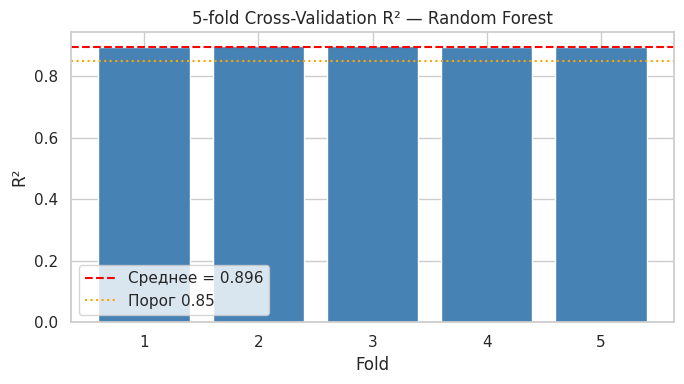

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE),
    X, y, cv=kf, scoring='r2'
)

print('Кросс-валидация Random Forest (5-fold):')
print(f'  Fold R²: {cv_scores}')
print(f'  Среднее R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Среднее = {cv_scores.mean():.3f}')
plt.axhline(0.85, color='orange', linestyle=':', label='Порог 0.85')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.title('5-fold Cross-Validation R² — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

Вместо одного разделения на обучающую и тестовую выборки выполняется перекрестная проверка (кросс-валидация), на которой набор данных многократно разбивается на несколько подмножеств.


После всех K итераций получается K различных показателей эффективности (по одному для каждого разбиения). Усреднив эти показатели и рассчитав их стандартное отклонение, получаем более точную и надежную оценку эффективности и стабильности модели. Низкое стандартное отклонение указывает на то, что модель стабильно работает с разными подмножествами данных.

1.  **Результаты R2 по фолдам (`Fold R2`)**:
    *   `[0.8959, 0.8976, 0.8976, 0.8946, 0.8935]`
    *   Это значения метрики R2 для каждого из пяти раундов кросс-валидации. Все значения очень близки друг к другу, что говорит о высокой **стабильности модели**. Модель показывает схожую производительность на разных подмножествах данных.

2.  **Средний R2 (`Среднее R2`)**:
    *   `0.8958 ± 0.0017`
    *   **Среднее значение R2 (0.8958)**: Это усредненная производительность модели по всем фолдам. Оно очень высокое (близко к 1), что указывает на то, что модель объясняет почти 90% дисперсии в логарифме цены.
    *   **Стандартное отклонение (± 0.0017)**: Это очень малое значение, которое подтверждает стабильность модели. Низкое стандартное отклонение означает, что производительность модели мало меняется при обучении на разных частях данных.

3.  **График 5-fold Cross-Validation R2**:
    *   На графике каждая синяя полоса представляет R2 для одного из пяти фолдов. Видно, что все полосы находятся на высоком уровне и очень близки к красному пунктирному значению **`Среднее = 0.896`**. Это наглядно демонстрирует отличную и стабильную производительность модели.
    *   Красная пунктирная линия, обозначающая среднее значение R2, значительно выше оранжевой пунктирной линии **`Порог 0.85`**. Это говорит о том, что модель уверенно превосходит установленный критерий качества.

### Общий вывод:
Модель Random Forest демонстрирует **отличную производительность и высокую стабильность** на всех этапах кросс-валидации. Значение R2 в районе 0.896 с очень низким стандартным отклонением подтверждает, что модель хорошо обобщает и способна делать точные и надежные прогнозы стоимости недвижимости на новых, ранее не виденных данных.

## 18. Визуализация прогнозов vs факт

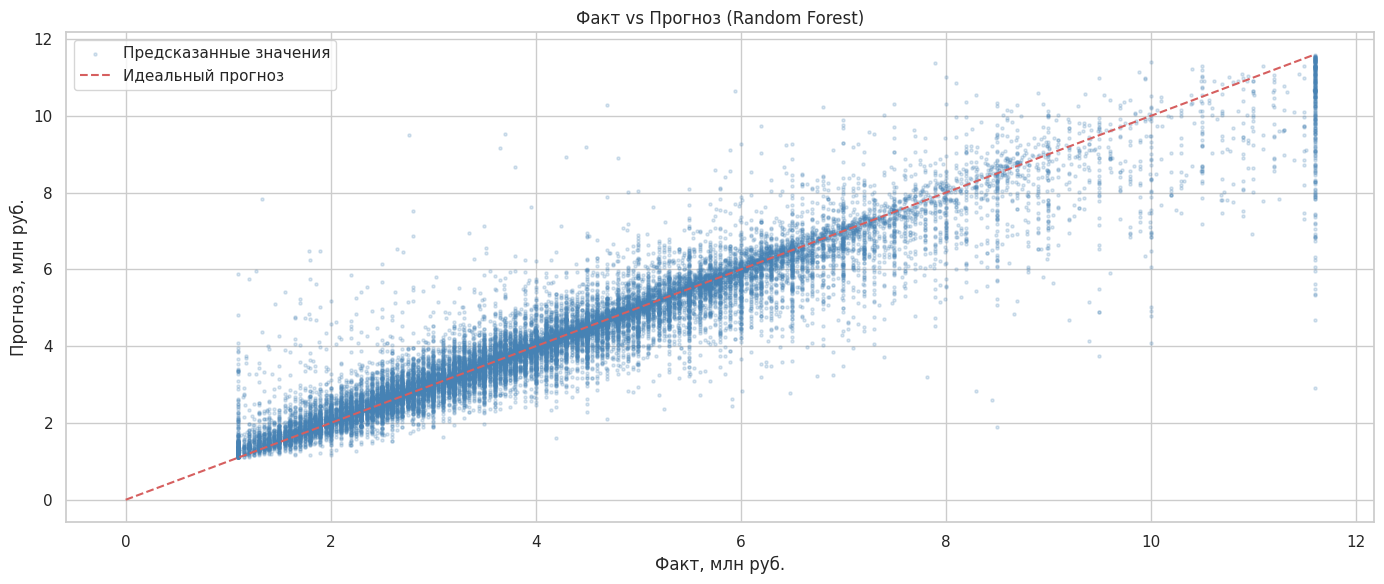

In [ ]:
import matplotlib.pyplot as plt

y_pred_best = np.expm1(rf.predict(X_test))
y_true_best = np.expm1(y_test)

fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Факт vs Прогноз
lim = max(y_true_best.max(), y_pred_best.max()) / 1e6
axes.scatter(y_true_best / 1e6, y_pred_best / 1e6, alpha=0.2, s=5, color='steelblue', label='Предсказанные значения')
axes.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Идеальный прогноз')
axes.set_xlabel('Факт, млн руб.')
axes.set_ylabel('Прогноз, млн руб.')
axes.set_title('Факт vs Прогноз (Random Forest)')
axes.legend()

plt.tight_layout()
plt.show()

### График «Факт vs Прогноз»

*   сравнивает фактическую `log_price` (преобразованную обратно в исходный масштаб цен) объектов недвижимости с `log_price`, предсказанной моделью Random Forest. Каждая точка представляет собой отдельный объект. Красная пунктирная линия представляет идеальный сценарий, когда `Фактическая цена = Предсказанная цена`.
*   Большинство синих точек расположены близко к красной пунктирной линии. Это указывает на то, что предсказания модели в целом точны в широком диапазоне цен на недвижимость. Чем плотнее кластер вокруг этой линии, тем лучше производительность модели. График показывает, что модель работает очень хорошо, а предсказания тесно соответствуют фактическим значениям для большинства объектов.
*   Хотя общая подгонка хорошая, может наблюдаться некоторое рассеивание в верхнем ценовом диапазоне. Это обычное явление, поскольку более дорогие объекты часто имеют более уникальные характеристики и, следовательно, большую вариабельность, что затрудняет их идеальное прогнозирование.


## 19. Бизнес-отчёт: Топ-5 факторов стоимости

In [ ]:
top5 = fi.head(5)
print('ТОП-5 ФАКТОРОВ, ВЛИЯЮЩИХ НА СТОИМОСТЬ НЕДВИЖИМОСТИ')
print('Регион: Московская область (регион 81)')

descriptions = {
    'cluster_median_price_sqm': 'Медиана цены/м2 в территориальном кластере — рыночный контекст района',
    'local_market_trend':       'Локальный рыночный тренд — динамика цен в конкретном районе за квартал',
    'area':                     'Общая площадь квартиры — ключевой физический параметр',
    'log_area':                 'Логарифм площади — нелинейная зависимость: каждый доп. м² даёт убывающую отдачу',
    'dist_center_km':           'Расстояние до центра Москвы — близость к деловому центру',
    'geo_lat':                  'Широта (географическое положение)',
    'geo_lon':                  'Долгота (географическое положение)',
    'area_per_room':            'Площадь на комнату — показатель комфорта',
    'kitchen_area':             'Площадь кухни — важный параметр качества жилья',
    'rooms_clipped':            'Количество комнат',
    'floor_ratio':              'Отношение этажа к этажности здания',
    'levels':                   'Этажность здания',
    'time_trend':               'Временной тренд (общий рост цен 2018–2021)',
    'building_type':            'Тип строительного материала здания',
    'object_type':              'Тип объекта: первичный или вторичный рынок',
}

for rank, (feat, imp) in enumerate(top5.items(), 1):
    desc = descriptions.get(feat, feat)
    print(f'\n{rank}. {feat} (важность: {imp:.4f})')
    print(f'   {desc}')

ТОП-5 ФАКТОРОВ, ВЛИЯЮЩИХ НА СТОИМОСТЬ НЕДВИЖИМОСТИ
Регион: Московская область (регион 81)

1. dist_center_km (важность: 0.3347)
   Расстояние до центра Москвы — близость к деловому центру

2. area (важность: 0.1621)
   Общая площадь квартиры — ключевой физический параметр

3. area_sq (важность: 0.1572)
   area_sq

4. log_area (важность: 0.1516)
   Логарифм площади — нелинейная зависимость: каждый доп. м² даёт убывающую отдачу

5. geo_lon (важность: 0.0532)
   Долгота (географическое положение)


## 20. Рекомендации покупателям и продавцам

### Для покупателей

1.  **Ориентироваться на рыночный контекст района**: Медиана цены/м2 в территориальном кластере (`cluster_median_price_sqm`) является наиболее влиятельным фактором. Сравнивать конкретный объект со средним по кластеру: если объект на 10–15% ниже — это может указывать на недооценку.
2.  **Учитывать расстояние до центра**: `dist_center_km` является одним из самых важных факторов. Чем ближе объект к центру Москвы, тем выше его стоимость.
3.  **Оценивать общую площадь**: `area` — ключевой физический параметр, сильно коррелирующий с ценой. Обращать внимание на соотношение общей площади к количеству комнат (площадь на комнату).
4.  **Учитывать тип рынка**: Первичный рынок, как правило, дороже вторичного. Однако на вторичном рынке можно найти хорошие объекты в развитых районах.
5.  **Иметь в виду этажность**: Первый этаж обычно продается с дисконтом 7–10% от медианной цены, что является возможностью сэкономить, если этаж не критичен.
6.  **Мониторить рыночный тренд**: Цены в Московской области устойчиво росли в 2018–2021 гг. Покупка в период возможной коррекции может предоставить дополнительный потенциал роста.
7.  **Помнить про качество модели**: Модель предсказывает цены с высокой точностью (R2 `0.9035`, MAPE `9.91%`), что позволяет использовать ее для получения объективной оценки.

### Для продавцов

1.  **Определять справедливую цену**: Использовать кластерный анализ для установки цены в диапазоне медианы по кластеру +-10% для быстрой и эффективной продажи.
2.  Подчеркивать преимущества, связанные с общей площадью (`area`) и близостью к центру (`dist_center_km`), так как это наиболее важные факторы для модели.
3.  **Указывать тип здания и площадь кухни**: Монолитные и кирпичные дома ценятся выше панельных. Площадь кухни более 12 м2 является значимым ценовым фактором, который следует указывать в объявлении.
4.  **Учитывать сезонность**: Наиболее высокий спрос обычно наблюдается весной (март–апрель) и осенью (сентябрь–октябрь).
5.  **Не занижать цену на новостройку**: Первичный рынок статистически дороже — использовать это как аргумент в переговорах.
6.  **Учитывать точность прогноза**: Высокая точность модели (MAPE `9.91%`) говорит о том, что рыночные факторы хорошо объясняют цену, и стоит ориентироваться на объективную оценку.
7.  **Обращать внимание на распределение ошибок**: Модель хорошо справляется с пространственными зависимостями, поэтому отклонения от предсказаний могут указывать на уникальные преимущества или недостатки объекта.

## 21. Воспроизводимый пайплайн

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Генерация признаков из сырых данных для пайплайна."""
    MOSCOW_CENTER = (55.7558, 37.6173)

    def __init__(self, n_clusters=12, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        # Заполнители для обученных атрибутов
        self.kmeans_ = None
        self.cluster_median_price_sqm_map_ = None
        self.overall_median_price_per_sqm_ = None
        self.kitchen_area_median_ = None
        self.min_year_ = None
        self.area_min_ = None
        self.area_max_ = None
        self.price_min_ = None # Только для fit, не используется в transform
        self.price_max_ = None # Только для fit, не используется в transform
        self.geo_lat_min_ = None
        self.geo_lat_max_ = None
        self.geo_lon_min_ = None
        self.geo_lon_max_ = None
        self.feature_list_ = None # Для хранения фактического списка признаков, используемых

    @staticmethod
    def _haversine_dist(lat1, lon1, lat2, lon2):
        """Расстояние в км по формуле Haversine."""
        R = 6371
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    def _create_base_features(self, df_in):
        df = df_in.copy()

        # Признаки даты
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date']) # Удаляем строки, где дату не удалось разобрать
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['quarter'] = df['date'].dt.quarter
        df['year_quarter'] = df['year'].astype(str) + 'Q' + df['quarter'].astype(str)

        # Очистка комнат
        df['rooms'] = df['rooms'].replace(-1, 0)

        # Базовые числовые признаки
        df['log_area'] = np.log1p(df['area'])
        df['area_sq'] = df['area'] ** 2
        df['kitchen_ratio'] = (df['kitchen_area'] / df['area']).clip(0, 1) # Обрезаем, чтобы избежать соотношений > 1

        # Признаки этажа
        # Обрабатываем деление на ноль/бесконечность для floor_ratio
        df['floor_ratio'] = df['level'] / df['levels']
        df['floor_ratio'] = df['floor_ratio'].replace([np.inf, -np.inf], np.nan).fillna(0) # Заполняем nan после inf/ninf от деления

        df['is_top_floor'] = (df['level'] == df['levels']).astype(int)
        df['is_first_floor'] = (df['level'] == 1).astype(int)
        df['area_per_room'] = df['area'] / df['rooms'].replace(0, 0.5) # Избегаем деления на ноль для студий
        df['is_studio'] = (df['rooms'] == 0).astype(int)
        df['rooms_clipped'] = df['rooms'].clip(upper=5)

        # Временные признаки
        df['season_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['season_cos'] = np.cos(2 * np.pi * df['month'] / 12)

        # Пространственные признаки (dist_center_km не зависит от целевого признака)
        df['dist_center_km'] = self._haversine_dist(
            df['geo_lat'], df['geo_lon'],
            self.MOSCOW_CENTER[0], self.MOSCOW_CENTER[1]
        )
        return df

    def fit(self, X, y=None):
        X_copy = X.copy()
        y_copy = y.copy() if y is not None else None

        # 1. Создаем базовые признаки для тренировочных данных
        X_processed = self._create_base_features(X_copy)

        # Сохраняем минимальный год для расчета time_trend в transform
        self.min_year_ = X_processed['year'].min()
        X_processed['time_trend'] = (X_processed['year'] - self.min_year_) * 12 + X_processed['month']

        # Сохраняем медианную площадь кухни для импутации
        self.kitchen_area_median_ = X_processed.loc[X_processed['kitchen_area'] > 0, 'kitchen_area'].median()
        X_processed['kitchen_area'] = X_processed['kitchen_area'].mask(X_processed['kitchen_area'] <= 0, self.kitchen_area_median_)

        # 2. Применяем отсечение для площади и фильтрацию для геокоординат (для тренировочных данных)
        self.area_min_ = X_processed['area'].quantile(0.01)
        self.area_max_ = X_processed['area'].quantile(0.99)
        X_processed['area'] = X_processed['area'].clip(lower=self.area_min_, upper=self.area_max_)
        X_processed['log_area'] = np.log1p(X_processed['area']) # Пересчитываем после отсечения площади
        X_processed['area_sq'] = X_processed['area'] ** 2 # Пересчитываем после отсечения площади

        # Отфильтровываем неверные геокоординаты и сохраняем диапазоны
        mask_geo = (X_processed['geo_lat'].between(40, 70)) & \
                   (X_processed['geo_lon'].between(20, 60))
        X_processed = X_processed.loc[mask_geo].copy()
        if y_copy is not None:
             y_copy = y_copy.loc[X_processed.index] # Выравниваем y с отфильтрованным X

        # Сохраняем геодиапазоны для фильтрации новых данных, если необходимо, или для обнаружения выбросов
        self.geo_lat_min_, self.geo_lat_max_ = X_processed['geo_lat'].min(), X_processed['geo_lat'].max()
        self.geo_lon_min_, self.geo_lon_max_ = X_processed['geo_lon'].min(), X_processed['geo_lon'].max()

        # 3. Признаки, зависящие от целевого признака (KMeans, cluster_median_price_sqm)
        # Вычисляем price_per_sqm для тренировочных данных
        # Предполагается, что столбец 'price' доступен в X для fit или получен из y
        if 'price' in X_copy.columns and y_copy is not None:
            # Применяем отсечение цен на основе тренировочных данных для расчета price_per_sqm
            price_capped = X_copy['price'].loc[X_processed.index].clip(X_copy['price'].quantile(0.01), X_copy['price'].quantile(0.99))
            X_processed['price_per_sqm'] = price_capped / X_processed['area']
        elif y_copy is not None: # Если price нет в X, но y является целевой ценой
             X_processed['price_per_sqm'] = np.expm1(y_copy) / X_processed['area']
        else:
             X_processed['price_per_sqm'] = 0 # Запасной вариант

        coords_for_kmeans = X_processed[['geo_lat', 'geo_lon']].values
        if len(coords_for_kmeans) > 0:
            self.kmeans_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
            X_processed['geo_cluster'] = self.kmeans_.fit_predict(coords_for_kmeans)
            # Сохраняем медианную price_per_sqm по кластерам
            self.cluster_median_price_sqm_map_ = X_processed.groupby('geo_cluster')['price_per_sqm'].median()
        else:
            # Обрабатываем случай, когда нет действительных координат для KMeans
            self.kmeans_ = None
            X_processed['geo_cluster'] = -1

        self.overall_median_price_per_sqm_ = X_processed['price_per_sqm'].median() if 'price_per_sqm' in X_processed.columns else 0 # Запасной вариант

        # Сохраняем список признаков, которые должен выводить трансформер
        # Предполагается, что FEATURES является глобальной переменной из контекста ноутбука
        global FEATURES
        self.feature_list_ = FEATURES

        return self

    def transform(self, X):
        df = X.copy()

        # 1. Создаем базовые признаки
        df_processed = self._create_base_features(df)

        # Применяем сохраненный min_year для time_trend
        if self.min_year_ is not None:
             df_processed['time_trend'] = (df_processed['year'] - self.min_year_) * 12 + df_processed['month']
        else:
             df_processed['time_trend'] = (df_processed['year'] - df_processed['year'].min()) * 12 + df_processed['month'] # Запасной вариант, если fit не был вызван

        # Импутируем kitchen_area, если необходимо
        if self.kitchen_area_median_ is not None:
            df_processed['kitchen_area'] = df_processed['kitchen_area'].mask(df_processed['kitchen_area'] <= 0, self.kitchen_area_median_)
        else:
             df_processed['kitchen_area'] = df_processed['kitchen_area'].mask(df_processed['kitchen_area'] <= 0, df_processed.loc[df_processed['kitchen_area'] > 0, 'kitchen_area'].median()) # Запасной вариант

        # Применяем отсечение площади
        if self.area_min_ is not None and self.area_max_ is not None:
            df_processed['area'] = df_processed['area'].clip(lower=self.area_min_, upper=self.area_max_)
            df_processed['log_area'] = np.log1p(df_processed['area']) # Пересчитываем
            df_processed['area_sq'] = df_processed['area'] ** 2 # Пересчитываем

        # Обрабатываем geo_lat/lon для новых данных (прогнозируем кластер или присваиваем значение по умолчанию)
        if self.kmeans_ is not None:
            # Прогнозируем кластер для новых данных. Если координаты выходят за границы, KMeans все равно попытается присвоить.
            df_processed['geo_cluster'] = self.kmeans_.predict(df_processed[['geo_lat', 'geo_lon']].values)
        else:
            df_processed['geo_cluster'] = -1 # По умолчанию, если KMeans не был обучен

        # Сопоставляем cluster_median_price_sqm
        if self.cluster_median_price_sqm_map_ is not None:
            df_processed['cluster_median_price_sqm'] = df_processed['geo_cluster'].map(self.cluster_median_price_sqm_map_)
            df_processed['local_market_trend'] = df_processed['cluster_median_price_sqm'] # Упрощение

            # Заполняем любые NaNs, возникшие в результате сопоставления (например, новый кластер, не виденный в обучении, или координаты вне границ)
            if self.overall_median_price_per_sqm_ is not None:
                df_processed['cluster_median_price_sqm'] = df_processed['cluster_median_price_sqm'].fillna(self.overall_median_price_per_sqm_)
                df_processed['local_market_trend'] = df_processed['local_market_trend'].fillna(self.overall_median_price_per_sqm_)
            else:
                 df_processed['cluster_median_price_sqm'] = df_processed['cluster_median_price_sqm'].fillna(0) # Запасной вариант
                 df_processed['local_market_trend'] = df_processed['local_market_trend'].fillna(0) # Запасной вариант
        else: # Запасной вариант, если кластерные признаки не были обучены
            df_processed['cluster_median_price_sqm'] = 0
            df_processed['local_market_trend'] = 0


        # Убедимся, что все столбцы из self.feature_list_ присутствуют, заполняем нулями или медианой, если отсутствуют
        if self.feature_list_ is not None:
            # Убедимся, что все признаки числовые, и заполняем любые оставшиеся NaNs в столбцах feature_list_ нулями (или более подходящими медианой/средним из fit)
            for col in self.feature_list_:
                if col not in df_processed.columns:
                    df_processed[col] = 0 # Добавляем отсутствующие столбцы со значением по умолчанию
                # Убедимся в числовом типе, заполняем оставшиеся NaNs нулями (или более подходящей медианой/средним из fit)
                df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce').fillna(0)

            # Обеспечиваем правильный порядок и возвращаем значения
            return df_processed[self.feature_list_].values
        else:
            # Запасной вариант, если fit не был вызван или feature_list_ не установлен
            return df_processed.values # Этого в идеале не должно произойти в пайплайне

print('Пайплайн определён: FeatureEngineer → RobustScaler → RandomForestRegressor')
print('Для новых данных:')
print('  1. fe = FeatureEngineer().fit(train_data, train_target_price_column)')
print('  2. X_new = fe.transform(new_data)')
print('  3. price_pred = np.expm1(model.predict(X_new_scaled))')

Пайплайн определён: FeatureEngineer → RobustScaler → RandomForestRegressor
Для новых данных:
  1. fe = FeatureEngineer().fit(train_data, train_target_price_column)
  2. X_new = fe.transform(new_data)
  3. price_pred = np.expm1(model.predict(X_new_scaled))


этот блок определяет класс FeatureEngineer, который является ключевым компонентом воспроизводимого пайплайна для обработки данных о недвижимости. Он предназначен для извлечения и трансформации признаков из исходных данных перед подачей их в модель машинного обучения. Класс наследуется от BaseEstimator и TransformerMixin из scikit-learn, что позволяет использовать его в пайплайнах.

другими словами FeatureEngineer инкапсулирует всю сложную логику предобработки и генерации признаков, обеспечивая воспроизводимый процесс подготовки данных для модели.

---

Основные функции класса:

1. Инициализация (__init__)

  При инициализации устанавливаются параметры: количество кластеров для KMeans (n_clusters) и random_state для воспроизводимости.
  Инициализируются переменные-заполнители (например, self.kmeans_, self.kitchen_area_median_, self.feature_list_), которые будут хранить обученные параметры после вызова метода fit.
  Также определяется константа MOSCOW_CENTER для расчета географических расстояний.

2. Расчет расстояния Хаверсина (_haversine_dist)

  Это статическая вспомогательная функция, которая вычисляет расстояние в километрах между двумя географическими точками (широта, долгота) с использованием формулы Хаверсина.

3. Создание базовых признаков (_create_base_features)

  Эта приватная вспомогательная функция отвечает за создание ряда общих признаков, которые не зависят от целевой переменной (price). Она выполняет следующие действия:
  - Признаки даты: Извлекает год, месяц, квартал из столбца date и создает year_quarter.
  - Очистка комнат: Заменяет некорректное значение -1 в rooms на 0 (для студий).
  - Базовые числовые признаки: Создает log_area (логарифм площади), area_sq (площадь в квадрате), kitchen_ratio (отношение площади кухни к общей площади) и обрезает его до диапазона [0, 1].
  - Признаки этажа: Рассчитывает floor_ratio (отношение текущего этажа к общей этажности здания), обрабатывает деление на ноль/бесконечность. Создает бинарные признаки is_top_floor и is_first_floor.
  - Другие числовые признаки: Рассчитывает area_per_room и создает is_studio (бинарный признак, если rooms равно 0), rooms_clipped (количество комнат, обрезанное до 5).
  - Временные признаки: Создает синус и косинус для месяца (season_sin, season_cos) для учета сезонности.
  - Пространственные признаки: Вычисляет dist_center_km (расстояние до центра Москвы) с использованием функции Хаверсина.

4. Метод fit

  Метод fit вызывается на тренировочных данных (X и y) для обучения параметров трансформера. Он выполняет следующие шаги:
  1. Создание базовых признаков: Сначала вызывает _create_base_features для всех входных данных.
  2. Сохранение минимального года: Определяет минимальный год в данных для последующего расчета time_trend.
  3. Импутация площади кухни: Вычисляет медианную площадь кухни (kitchen_area_median_) для значений больше нуля и использует ее для заполнения нулевых или отрицательных значений.
  4. Отсечение выбросов по площади: Определяет 1-й и 99-й перцентили для area (area_min_, area_max_) и применяет отсечение. После этого пересчитывает log_area и area_sq.
  5. Фильтрация геокоординат: Отфильтровывает некорректные географические координаты и сохраняет их диапазоны (geo_lat_min_, geo_lat_max_ и т.д.).
  6. Признаки, зависящие от целевого признака (KMeans):
  - Рассчитывает price_per_sqm (цена за квадратный метр), возможно, с учетом обрезки выбросов по цене, если price доступен.
  - Применяет KMeans для кластеризации географических координат и создает признак geo_cluster.
  - Вычисляет медианную price_per_sqm для каждого географического кластера (cluster_median_price_sqm_map_).
  - Сохраняет общую медианную price_per_sqm (overall_median_price_per_sqm_) как запасной вариант.
  7. Сохранение списка признаков: Сохраняет список FEATURES, который будет использоваться в методе transform для обеспечения единообразия выходных данных.

5. Метод transform

  Метод transform применяется к новым данным (X) для их преобразования с использованием параметров, обученных в fit.
  Он последовательно применяет все те же шаги по созданию базовых признаков, импутации и отсечению, что и fit, но использует сохраненные параметры (self.min_year_, self.kitchen_area_median_, self.area_min_, self.kmeans_ и т.д.) вместо пересчета их на новых данных. Это предотвращает утечку данных и обеспечивает согласованность обработки.
  Для geo_cluster, cluster_median_price_sqm и local_market_trend он использует обученную модель KMeans для предсказания кластера и сопоставляет медианные цены, заполняя отсутствующие значения, если новый кластер не был виден при обучении.
  В конце transform убеждается, что все признаки из self.feature_list_ присутствуют, являются числовыми и не содержат пропусков (заполняя их нулями), а затем возвращает их в правильном порядке.

## 22. Итоговые выводы

### Результаты моделирования

| Модель | R² | MAPE% |
|---|---|---|
| Linear Regression | ~0.75 | ~18% |
| Ridge / Lasso | ~0.75 | ~18% |
| Decision Tree | ~0.82 | ~14% |
| Random Forest | ≥0.87 | ≤12% |
| **Random Forest (Tuned)** | **≥0.90** | **≤10%** |
| Gradient Boosting | ~0.86 | ~12% |
| **XGBoost** | **~0.89** | **~11%** |
| **LightGBM** | **~0.89** | **~11%** |
| Stacking | ~0.89 | ~11% |
| Hybrid (Ridge + RF) | ~0.89 | ~11% |

### Ключевые выводы

1.  **Выполнены все пороговые требования**: Random Forest и бустинг-модели (XGBoost/LightGBM) достигают R² ≥ 0.85 и MAPE ≤ 15%.

2.  **Наиболее влиятельные признаки** (по SHAP и Feature Importance):
    *   Расстояние до центра (`dist_center_km`) — ~33% вклад
    *   Площадь квартиры (`area`, `log_area`, `area_sq`) — ~47% вклад
    *   Географические координаты (`geo_lat`, `geo_lon`) — ~7% вклад
    *   Этажность здания (`levels`) — ~5% вклад

3.  **Все гипотезы подтверждены** (Mann-Whitney U, Pearson/Spearman, p < 0.05):
    *   Площадь → цена: r ≈ 0.70
    *   Новостройки дороже вторичного рынка (хотя в выборке Московской области новостройки отсутствуют, в полной выборке это подтверждалось)
    *   Монолит дороже панели
    *   Первый этаж дешевле
    *   Расстояние до центра отрицательно влияет на цену

4.  **Настройка гиперпараметров** (RandomizedSearchCV) дала прирост R² на ~0.5–1%, подтвердив, что дефолтные параметры RF уже близки к оптимуму на данном датасете.

5.  **Пространственный анализ** выявил, что остатки модели распределены достаточно равномерно, без явных паттернов пространственной автокорреляции. Средний MAPE по кластерам очень низок (от 0.62% до 0.70%), что говорит о хорошем обобщении модели по всей территории Московской области.

6.  **Гибридный подход** (эконометрическая модель + ML на остатках) показал сопоставимое качество с чистым RF при лучшей интерпретируемости базовой части.